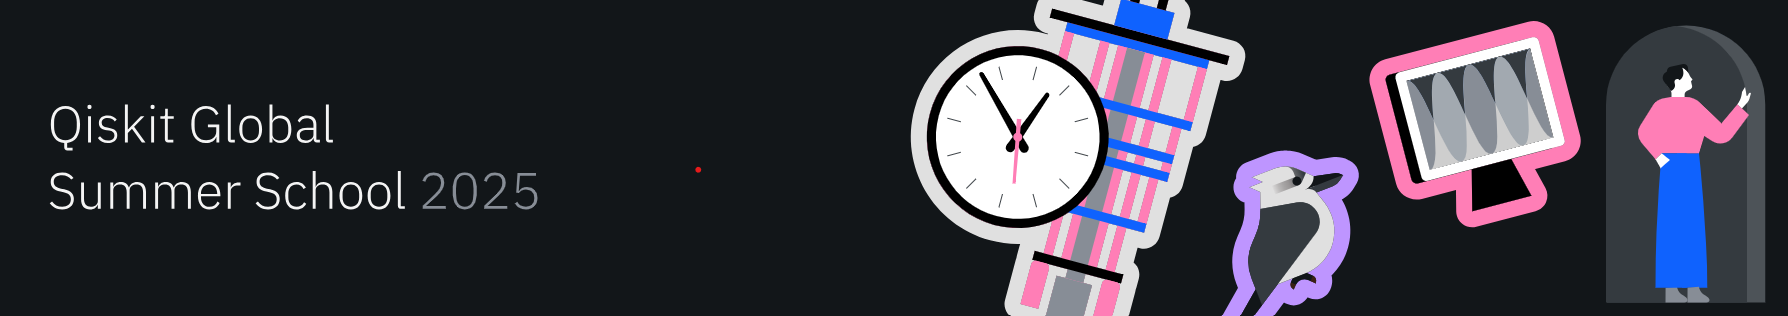


# ラボ2：ノイズを切り抜ける

このラボでは、量子ノイズの世界と、現在の量子コンピュータで良い結果を得るためにノイズの課題を乗り越えるための様々な手法について学びます。小規模な Max-cut 問題の文脈で、量子アルゴリズムを量子コンピュータで実行するために量子ノイズを低減するために踏むべきステップを一つずつ案内します。誤りを最小限に抑え、ノイズにもかかわらず結果が正しいままであることを保証するために、様々なトランスパイルやエラー緩和技術を探ります。最後に、ラボのまとめとして、これまでに紹介した全ての技術を実際の量子ハードウェア上で実装するボーナス課題を用意しています。

# 目次

0. [要件](#requirements)
1. [イントロダクション](#intro)  
    - [ラボの精神](#spirit)
    - [量子ノイズとは？](#quantum-noise)  
    - [ノイズの発生源](#sources)
        * [演習1: T1, T2が長く、ゲート忠実度が高く、読み出しエラーが小さい量子ビットを探す](#exercise_1)
2. [Max-cut問題](#max-cut)
    - [問題: グラフの定義](#the-graph)
    - [マッピング: グラフを量子コンピュータに変換](#the-mapping)
        * [演習2: Max-cut問題のイジングハミルトニアンを求める](#exercise_2)
    - [QAOAによる解法](#qaoa-solution)
    - [解の検証](#checking)
3. [ノイズ付き量子シミュレータ](#noisy-simulator)
    - [バックエンドの選択](#choosing-backend)
        * [演習3: エラーのカウント](#exercise_3)
    - [NEATによるエラー推定](#neat)
4. [トランスパイラ](#transpiler)
    - [2量子ビットゲートの最小化](#min-two-qubit)
    - [最適なレイアウトの探索](#opt-layout)
        * [演習4: 良いマッピングを全て見つける](#exercise_4)
        * [演習5: トランスパイラで最適レイアウトを見つける](#exercise_5)
5. [エラー緩和](#em)
    - [ゼロノイズ外挿（ZNE）](#zne)
        * [演習6a: 量子回路のグローバルフォールディングを実装](#exercise_6a)
        * [演習6b: 量子回路のローカルフォールディングを実装](#exercise_6b)
        * [演習7: ローカルゼロノイズ外挿（ZNE）を実装](#exercise_7)
6. [まとめ](#conclusions)
7. [ボーナスチャレンジ: スケールアップ！](#bonus)

<a id="requirements"></a>

## 0. 要件 

このチュートリアルを開始する前に、以下のライブラリがインストールされていることを確認してください。

* Qiskit SDK v2.0 （visualization サポート付） (`pip install 'qiskit[visualization]'`)
* Qiskit Runtime v0.22 以降 (`pip install qiskit-ibm-runtime`)
* Rustworkx (`pip install rustworkx`)
* Qiskit Aer v0.17
* Pylatexenc


In [1]:
# %pip install -U qiskit "qc-grader[qiskit,jupyter] @ git+https://github.com/qiskit-community/Quantum-Challenge-Grader.git"

In [2]:
import qiskit
import qc_grader

print(f"Qiskit version: {qiskit.__version__}")
print(f"Grader version: {qc_grader.__version__}")

Qiskit version: 2.1.1
Grader version: 0.22.12


Qiskit のバージョンが `>=2.0.0` で、Grader が `>=0.22.9` であることを確認してください。バージョンが低い場合は、カーネルを再起動して Grader を再インストールしてください。  
また、Lab 0に従ってすべてをセットアップし、以下のセルでテストしてください。

In [3]:
# アカウントが正しく保存されていることを確認してください
from qiskit_ibm_runtime import QiskitRuntimeService


service = QiskitRuntimeService(name="qgss-2025")
service.saved_accounts()

{'qgss-2025': {'channel': 'ibm_quantum_platform',
  'url': 'https://cloud.ibm.com',
  'token': 'cxkGGSsPsLFOp4IzswIFk-JEeUsKns0muIGxsAsRwSHg',
  'instance': 'crn:v1:bluemix:public:quantum-computing:us-east:a/3efbef98d82f4ca4b5cdd753e9f179e2:48f95bc0-755a-4f6b-9e43-664f3d8415e3::',
  'verify': True,
  'private_endpoint': False}}

In [4]:
import rustworkx as rx
import numpy as np
import matplotlib.pyplot as plt
from rustworkx.visualization import mpl_draw as draw_graph
from qiskit_ibm_runtime import QiskitRuntimeService
from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.quantum_info import SparsePauliOp, Statevector, DensityMatrix, Operator
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit.transpiler import Layout

from qiskit_ibm_runtime import (
    Session,
    EstimatorV2 as Estimator,
    SamplerV2 as Sampler,
    EstimatorOptions,
)
from qiskit_ibm_runtime.debug_tools import Neat
from qiskit_aer import AerSimulator

from utils import zne_method, plot_zne, plot_backend_errors_and_counts
from qc_grader.challenges.qgss_2025 import (
    grade_lab2_ex1,
    grade_lab2_ex2,
    grade_lab2_ex3,
    grade_lab2_ex4,
    grade_lab2_ex5,
    grade_lab2_ex6a,
    grade_lab2_ex6b,
)

## 1. イントロダクション <a id="intro"></a>

### 1.1 ラボの精神 <a id="spirit"></a>

*IBM量子ハードウェア上でのパフォーマンスを最大化するために、適切なトランスパイルとエラー緩和技術を使って実際の問題に取り組むプロセスを案内します。*

### 1.2 量子ノイズとは？ <a id="quantum-noise"></a>

ノイズは量子コンピュータの設計や利用において中心的な話題であり、現在のデバイスの主な特徴の一つです。しかし、量子情報においてノイズとは一体何を意味するのでしょうか？  
通常、ノイズとは量子状態の測定結果に期待される結果を乱す、望ましくない変換全般を指します。これには、エラーを引き起こす様々な要因が含まれ、主に2つのグループに分類できます：

- コヒーレントエラー：量子操作（ゲート）の適用における小さく一貫したミスによって引き起こされます。これらのエラーはユニタリーであり、情報を破壊せず、理論的には逆転可能です。典型的な例は、あるゲートが本来 $\theta$ だけ回転させるべきところを、キャリブレーションの不完全さにより $\theta+\varepsilon$ だけ回転させてしまう場合です。例えば、Hadamard ゲートがわずかにミスキャリブレーションされていると、完全な重ね合わせを作れず、測定結果にバイアスが生じます。
- インコヒーレントエラー：これらのエラーの起源は量子的であり、量子システムが環境と相互作用することで発生します。インコヒーレントエラーは、現在の量子コンピュータの多くはミリケルビンオーダーの低温に冷却され、不要な相互作用を減らしコヒーレンスを維持しています。これらの相互作用は混合状態を生み出し、出力にランダム性を導入するため、特に問題となります。具体例としては $T_1$ 緩和時間があり、励起状態 $|1\rangle$ の量子ビットが時間とともに基底状態 $|0\rangle$ へ自発的に崩壊する現象を記述します。測定が遅れると、この崩壊により量子ビットが状態を反転させ、誤った結果につながることがあります。

### 1.3 ノイズの発生源 <a id="sources"></a>

上述の通り、ノイズの発生源には、電磁パルスとしての量子ゲートの不完全な実装、読み出しエラー、量子システムのデコヒーレンスなど、様々な要因があります。

量子コンピュータ（または量子ビット）がどれだけノイズに強いかを評価するための指標は様々ありますが、その中からいくつかを選んで扱います：

* T1：緩和時間。状態 $|1\rangle$ の量子ビットが状態 $|0\rangle$ へ崩壊する速さを測る減衰定数
* T2：位相緩和時間。状態 $|+\rangle$ の量子ビットが $|+\rangle$ と $|-\rangle$ の区別がつかない混合状態になるまでの速さを測る減衰定数
* 1量子ビットゲート忠実度：ハードウェアが実際に行う操作 $\mathcal{E}$ が理想的な1量子ビットユニタリー$U$とどれだけ近いかを定量化します。忠実度1は理想通りの動作を意味します。
* 2量子ビットゲート忠実度：ハードウェアが実際に行う操作 $\mathcal{E}_2$ が理想的な2量子ビットユニタリー $U_2$ とどれだけ近いかを定量化します。これらのゲートはより複雑なため、忠実度は低くなりがちです。1なら完全一致です。
* 読み出し割り当てエラー：量子ビットが誤って測定される確率。測定された古典ビットが、測定直前の量子ビットの実際の量子状態と一致しないことを意味します。

ある特定の IBM Quantum デバイスの情報は [IBM Quantum Cloud Platform](https://quantum.cloud.ibm.com/computers) から確認できます。分析したいデバイスを選択すると、各量子ビットの詳細な特性やマシン全体の概要をインタラクティブに確認できます。下の画像は `ibm_brisbane` デバイスの概要例です。

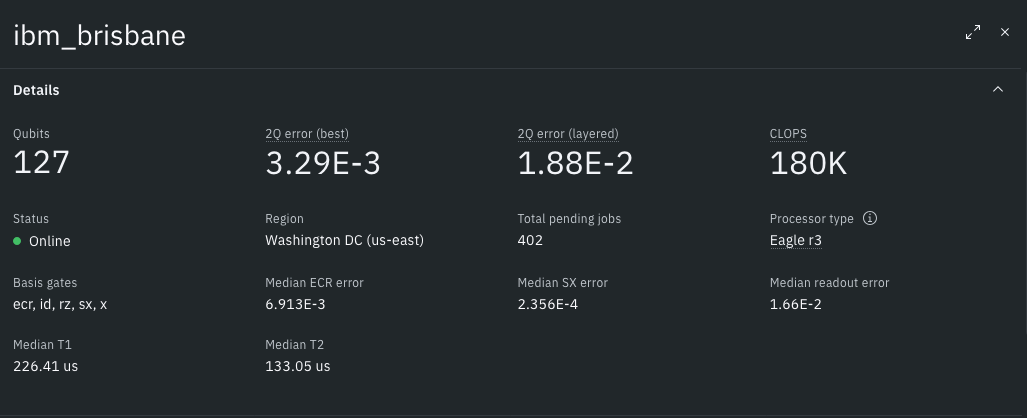

このデバイスの情報はコードを通して直接アクセスすることもできます。

実際にやってみましょう！

<a id="exercise_1"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 1: ベストな量子ビットを見つける </b> 

**あなたの目標:** T1・T2が長く、ゲート忠実度が高く、読み出しエラーが小さい量子ビットを探してください。

この最初の演習では、以下の各指標について最良の値と、その値を持つ量子ビットまたは量子ビットのペアを答えてください：

- 緩和時間：T1
- 位相緩和時間：T2
- 読み出しエラー
- 1量子ビットゲートエラー：'PauliX'エラー
- 2量子ビットゲートエラー：'Ecr'エラー

回答をよりロバストにするために、どんなバックエンドでも動作するルーティンを記述してください。

<i>注1：ECRゲートはこのバックエンド固有の2量子ビットゲートであり、他の量子デバイスでは CZ や CNOT ゲートの場合もあります。バックエンドの基底ゲートは [backend.basis_gates](/docs/api/qiskit-ibm-runtime/ibm-backend) を使って確認できます。</i>

<i>注2：最も性能の良い量子ビットとその値は時間とともに変化する可能性があるため、Pythonの `min()` と `max()` 関数を使って、実行の度に量子ビットを直接調べることをお勧めします。</i>


</div>

以下のコードは、`ibm_brisbane` バックエンドからすべての量子ビットのプロパティを取得し、配列に格納する方法を示しています。関数を実装する際の参考にしてください。

In [9]:
# プロパティの配列を作成
service = QiskitRuntimeService(name="qgss-2025")
# 特定のバックエンドを定義
brisbane_backend = service.backend("ibm_brisbane")
# システムのプロパティ、量子ビットの数、および結合マップを取得
properties = brisbane_backend.properties()
num_qubits = brisbane_backend.num_qubits
coupling_map = brisbane_backend.coupling_map

# バックエンドのすべての量子ビットのメトリックのさまざまなリストを定義
t1, t2, gate_error_x, readout_error, gate_error_ecr = [], [], [], [], []
for i in range(num_qubits):
    t1.append(properties.t1(i))
    t2.append(properties.t2(i))
    gate_error_x.append(properties.gate_error(gate="x", qubits=i))
    readout_error.append(properties.readout_error(i))
for pair in coupling_map:
    gate_error_ecr.append((properties.gate_error(gate="ecr", qubits=pair), pair))

print(gate_error_ecr)

[(0.0044707493164252154, (1, 0)), (0.007828007542867471, (2, 1)), (0.004936423917009741, (3, 2)), (0.003277870533883731, (4, 3)), (0.004227394653212008, (4, 5)), (0.0030154125399761977, (4, 15)), (0.005969543988337878, (6, 5)), (0.007185885128069114, (6, 7)), (0.006745271824343341, (7, 8)), (0.0077887573829983625, (8, 9)), (0.006513196007480432, (10, 9)), (0.005617332653719748, (10, 11)), (0.005592315834365341, (11, 12)), (0.00518312239047497, (12, 17)), (0.006615986657552281, (13, 12)), (0.005814030125588593, (14, 0)), (0.006881285707573098, (14, 18)), (0.003794312334132549, (15, 22)), (0.004520298198965489, (16, 8)), (0.004639153368668381, (16, 26)), (0.005181917842028566, (17, 30)), (0.0032609063951409833, (18, 19)), (0.002749217267727949, (20, 19)), (0.03893433821374631, (20, 33)), (0.003695171143348136, (21, 20)), (0.006762933862653225, (21, 22)), (0.005263448926561082, (22, 23)), (0.00574590500274666, (24, 23)), (0.18442330076487157, (24, 34)), (0.005423219990294853, (25, 24)), (

In [15]:
def find_best_metrics(backend: QiskitRuntimeService.backend) -> list[tuple[int or list, float]]:
    """ベストなパフォーマンスを持つ量子ビットと量子ビットペアを、さまざまなハードウェアメトリックに基づいて見つける"""
    #---- TODO : Task 0 ---
    #backendのメトリクス リストを定義する
    t1, t2, gate_error_x, readout_error, gate_error_ecr = [], [], [], [], []
    
    properties = backend.properties()
    num_qubits = backend.num_qubits
    coupling_map = backend.coupling_map

    basis_gate = backend.basis_gates[0]
    
    for i in range(num_qubits):
        t1.append(properties.t1(i))
        t2.append(properties.t2(i))
        gate_error_x.append(properties.gate_error(gate="x", qubits=i))
        readout_error.append(properties.readout_error(i))
    for pair in coupling_map:
        gate_error_ecr.append((properties.gate_error(gate=basis_gate, qubits=pair), pair))
    
    # ---- TODO : Task 1 ---
    # 目標: 以下のメトリクスのベストな値と量子ビットのインデックスまたはインデックスを取得する

    # ベストな量子ビット（index_t1_max）を見つけ、最長の T1 とその値（max_t1）を取得
    index_t1_max = np.argmax(t1)
    max_t1 = t1[index_t1_max]

    # ベストな量子ビット（index_t2_max）を見つけ、最長の T2 とその値（max_t2）を取得
    index_t2_max = np.argmax(t2)
    max_t2 = t2[index_t2_max]

    # ベストな量子ビット（index_min_x_error）を見つけ、最小の x ゲートエラーとその値（min_x_error）を取得
    index_min_x_error = np.argmin(gate_error_x)
    min_x_error = gate_error_x[index_min_x_error]

    # ベストな量子ビット（index_min_readout）を見つけ、最小の読み出しエラーとその値（min_readout）を取得
    index_min_readout = np.argmin(readout_error)
    min_readout = readout_error[index_min_readout]

    # 最小の ecr エラーを持つベストな量子ビットペア（min_ecr_pair）とその値（min_ecr_error）を取得

    min_ecr_err_pair = min(gate_error_ecr, key=lambda err_pair: err_pair[0])
    min_ecr_pair = min_ecr_err_pair[1]
    min_ecr_error = min_ecr_err_pair[0]
    
    # --- End of TODO ---

    solutions = [
        [int(index_t1_max), max_t1],
        [int(index_t2_max), max_t2],
        [int(index_min_x_error), min_x_error],
        [int(index_min_readout), min_readout],
        [list(min_ecr_pair), min_ecr_error],
    ]
    return solutions

In [16]:
# 次のコードを実行して、課題を提出してください

grade_lab2_ex1(find_best_metrics)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


お疲れさまでした！デバイスのプロパティへアクセスし、特定の特徴を持つ量子ビットを検索する方法を学びました。
ここで「最良のメトリクスを持つ量子ビットだけを選べばいいのでは？」と思うかもしれませんが、実はそう簡単ではありません。

取得した量子ビットのインデックスを出力してみると、それらがデバイス上の特定の領域に集まっているわけではなく、むしろ様々な場所に分散していることが分かります。これは重要な課題を示しています。例えば、緩和時間（T1）が長い量子ビットが、同時に1量子ビットゲートエラーが大きい場合もありますし、その逆もあり得ます。こうしたトレードオフがあるため、単一のメトリクスだけで量子ビットを選ぶと、特定の量子アルゴリズムにとって最適なパフォーマンスが得られないことがあります。さらに、カップリングマップに示されているように、全ての量子ビットが互いに接続されているわけではありません。これら全ての要素が、量子ビットのレイアウト選択を非常に複雑でありながらも魅力的な課題にしています。

幸いなことに、Qiskit にはこの問題を解決するための専用ツール、**トランスパイラ**があります。

後のセクションではトランスパイラについて詳しく学びます。

# 2. 問題： Max-cut <a id="max-cut"></a>
Max-cut 問題は、NP 困難に分類されるグラフ問題です。これは、多項式時間で解けるアルゴリズムが存在しないことを意味します。Max-cut は、クラスタリング、ネットワーク科学、統計物理学、機械学習など幅広い分野で応用される最適化問題です。この問題の目標は、グラフのノードを2つのグループに分割し、その分割によって横切るエッジの数を最大化することです。
具体例で見てみましょう。

下の図は、5ノードの問題における Max-cut の解を示しており、グラフがどのように分割され、カットされるエッジ数が最大化されているかを表しています。別の見方をすると、グラフの max-cut を見つけるとは、ノードを2つのグループに分け、異なるグループ間を結ぶエッジの数ができるだけ多くなるようにすることです。

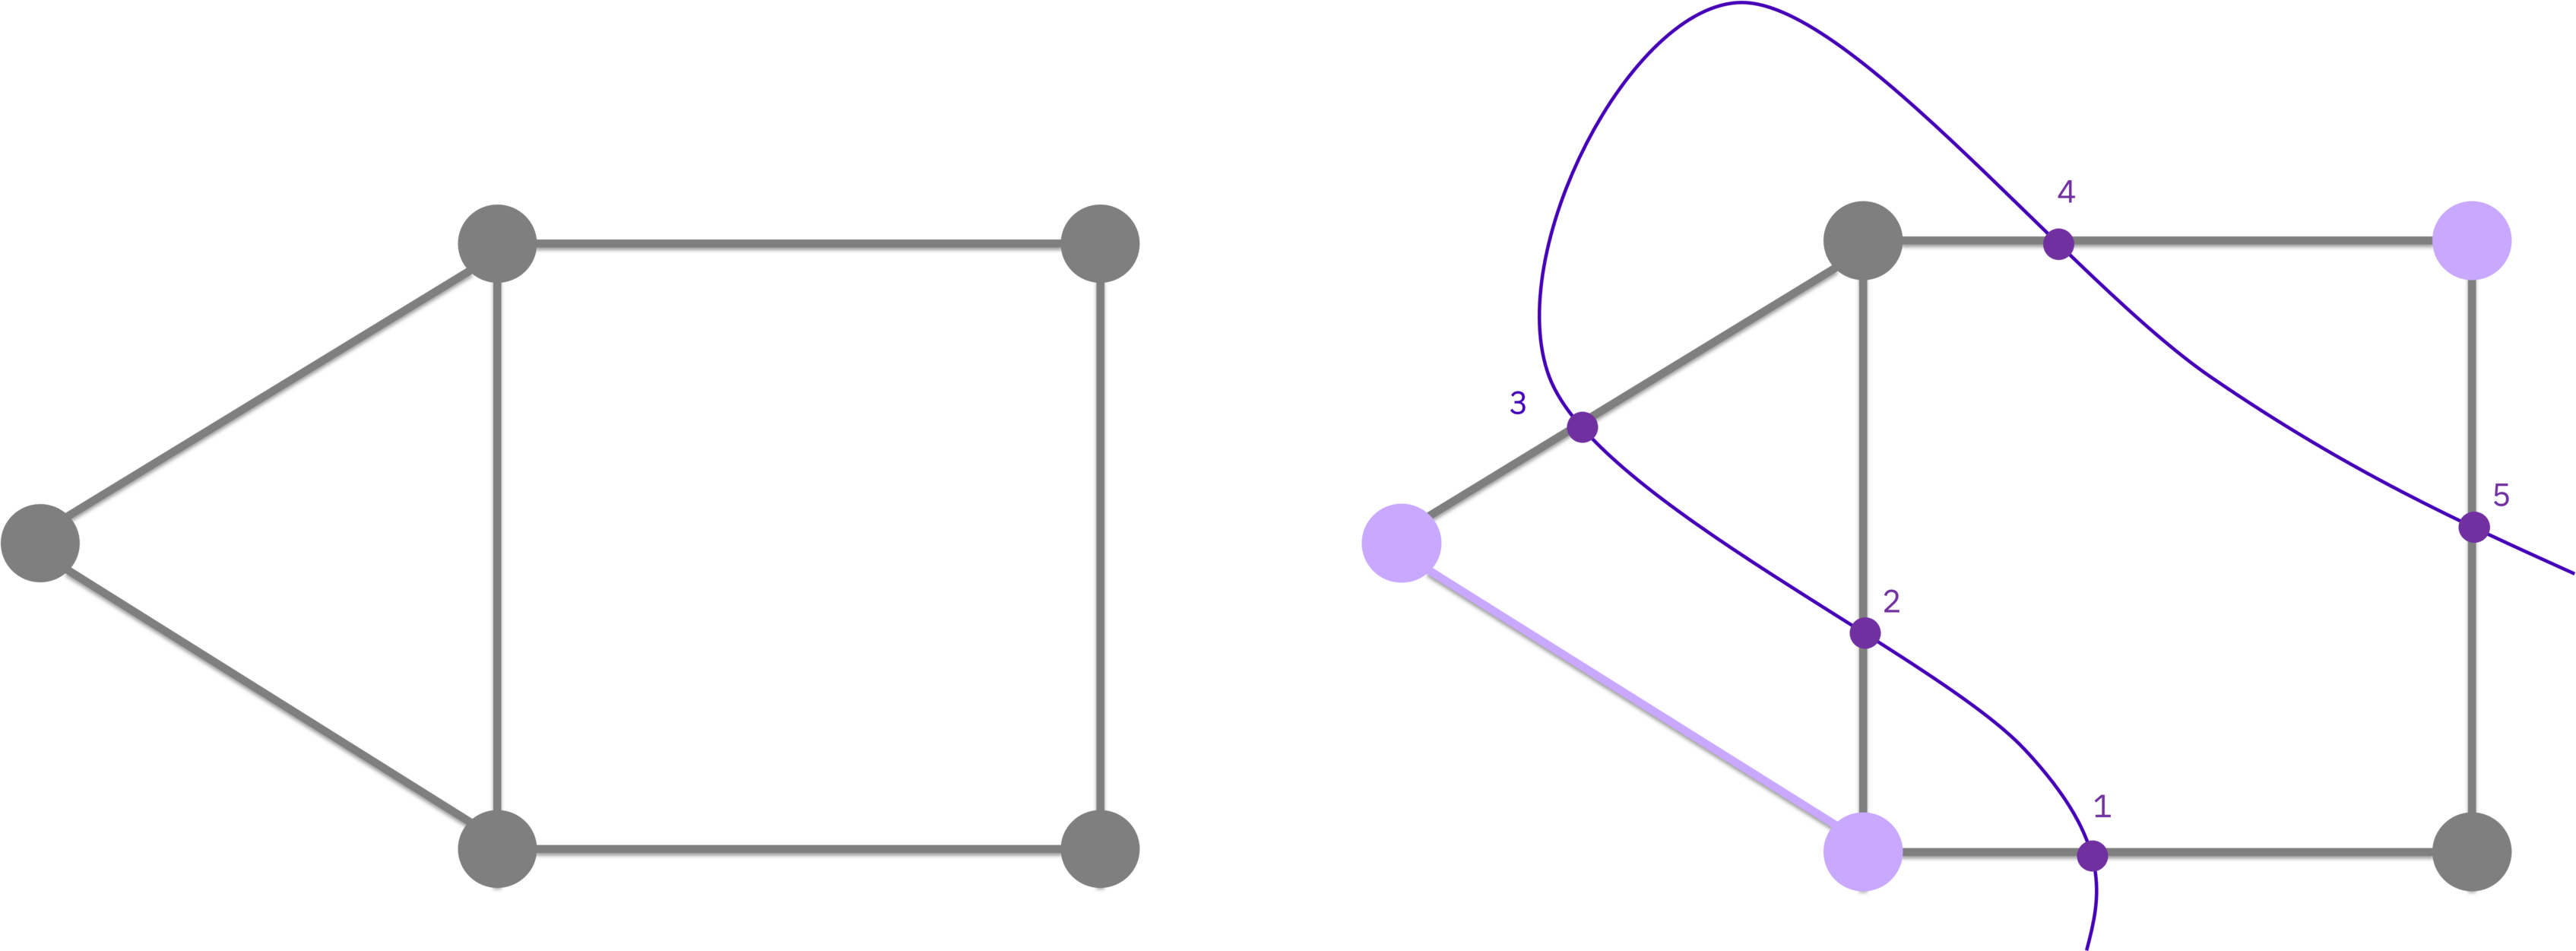

このラボでは、量子アルゴリズムを用いて Max-cut 問題を解きます。また、量子ノイズが解にどのような影響を与えるかを調べ、その影響を低減するための戦略についても議論し、ノイズがあっても正確な結果が得られるようにします。

## 2.1 問題：グラフの定義 <a id="the-graph"></a>
Max-cut 問題の概要が分かったところで、実際に max-cut を求めたい特定のグラフを選びましょう。ここでは、仮想的な量子コンピュータのカップリングマップ（全結合型）をグラフとして選びます$^*$。

$^*$ ただし、実際には最後の量子ビットは最初の量子ビットと接続されていません。これは問題の対称性を意図的に壊し、解の数を減らすためです。

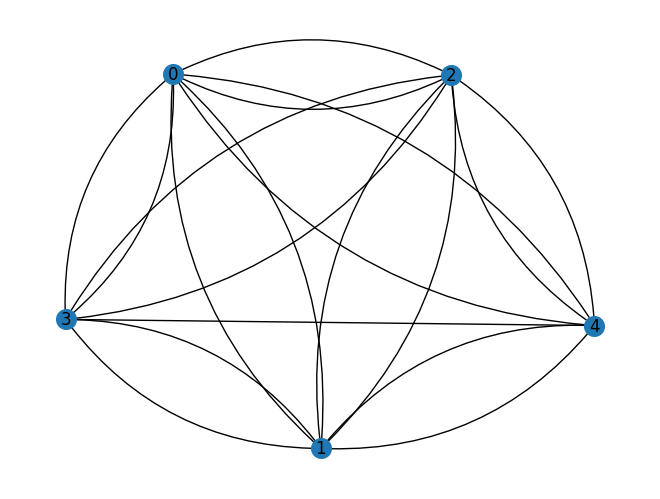

In [17]:
# シードの定義
seed = 43
# ノード数の定義
n = 5
# グラフの定義
graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, n, 1))
generic_backend = GenericBackendV2(n, seed=seed)
weights = 1
# グラフをわざと非対称にして、解のセットを小さくする
graph.add_edges_from([(edge[0], edge[1], weights) for edge in generic_backend.coupling_map][:-1])
draw_graph(graph, node_size=200, with_labels=True, width=1)

## 2.2 マッピング：グラフを量子コンピュータに変換 <a id="the-mapping"></a>

グラフ問題を量子コンピュータで解くには、まずそれをコンピュータが理解できる言語に変換する必要があります。一般的かつ強力な方法は、最適化問題を**ハミルトニアン**の形式で表現することです。ハミルトニアンとは、量子力学における系の全エネルギーを記述する数学的対象です。問題の解は、このハミルトニアンの最低エネルギー状態（「基底状態」）に符号化されます。

このような問題を定式化する際によく使われる2つの言語があります。

1.  **QUBO（Quadratic Unconstrained Binary Optimization：二次非制約バイナリ最適化）**

この形式は、計算機科学や古典的な最適化分野でよく使われます。バイナリ変数 **x<sub>i</sub> ∈ {0, 1}** を用い、次の形式の目的関数を最小化します：

$$ \text{minimize} \sum_{i} Q_{ii}x_{i} + \sum_{i<j} Q_{ij}x_{i}x_{j} $$

### 2. **イジングモデル（Ising Model）**

この形式は統計物理学に由来し、量子系に自然に適合します。スピン変数 **s<sub>i</sub> ∈ {+1, -1}** を用い、次の形式のエネルギーハミルトニアンを最小化します：

$$ H = -\sum_{i} h_{i}s_{i} - \sum_{i<j} J_{ij}s_{i}s_{j} $$

これら2つの形式は同値であり、以下の単純な線形変換を用いて相互に変換可能です：

**s<sub>i</sub> = 2x<sub>i</sub> - 1**

このラボでは、グラフ問題を直接**イジングハミルトニアン**にマッピングします。これは量子コンピュータにとって最も直接的な方法です。なぜなら、パウリZ演算子の固有値が **+1** と **-1** であり、イジングモデルのスピン変数 **s<sub>i</sub>** と完全に対応しているからです。

### Max-cut 問題からイジングハミルトニアンへ

グラフ \$G = (V, E)\$ 上の Max-cut 問題では、頂点集合 $V$ を2つのグループに分割し、異なるグループに属する頂点を結ぶエッジの数を最大化することが目的です。

この目的をスピン変数 **s<sub>i</sub>** を用いて表現します。接続された2つのノード `i` と `j` が異なるグループにある場合（s<sub>i</sub> ≠ s<sub>j</sub>）、積 $s_i * s_j$ は -1 になります。同じグループにある場合は +1 になります。

したがって、**カットを最大化するには、接続されたエッジすべてに対する $s_i * s_j$ の合計を最小化すればよい**ということになります。これにより、次のようなコストハミルトニアンが得られます：

$$
H_{cost} = \sum_{(i,j) \in E} Z_i \otimes Z_j
$$

ここでは、古典的なスピン変数 `s_i` を、それに対応する量子版であるパウリZ演算子 **Z<sub>i</sub>** に置き換えています。Z<sub>i</sub> は `i` 番目の量子ビットに作用します。このハミルトニアンの基底状態が、エネルギーを最小にする量子ビット状態（`|0⟩` または `|1⟩` の配置）であり、それが Max-cut 問題の解になります。

より詳しい情報は、以下の[チュートリアル](https://quantum.cloud.ibm.com/docs/tutorials/quantum-approximate-optimization-algorithm)をご参照ください。

これこそが、次の演習で取り組む内容です！


<a id="exercise_2"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 2: グラフからハミルトニアンへ </b> 

**あなたの目標:** 
'graph' オブジェクトをイジングハミルトニアンに変換し、Max-cut 問題のコスト関数を求めてください。

この2つめの演習では、与えられたグラフ問題を恒等演算子とパウリ演算子を用いてハミルトニアンにマッピングする方法を見つけてください。




</div>

<div class="alert alert-info">
<details>
    <summary> <b>ヒント</b> 💡: （クリックで展開）</summary>
    このハミルトニアンを構築する勘所は、n×n のヒルベルト空間を考え、グラフのエッジの数だけ項を追加することです。各エッジで接続されたノードはパウリ Z 行列で表し、それ以外のノードは恒等演算子で表します。<br> <br>
    上で述べたチュートリアル <a href="https://quantum.cloud.ibm.com/docs/tutorials/advanced-techniques-for-qaoa">Advanced techniques for QAOA</a>の<a href=https://quantum.cloud.ibm.com/docs/tutorials/advanced-techniques-for-qaoa#graph--hamiltonian>Graph to Hamiltonian</a> セクションに、役立つ関数があるので参照してください。

</details>
</div>

In [21]:
def graph_to_Pauli(graph: rx.PyGraph) -> list[tuple[str, float]]:
    """Convert the graph to Pauli list."""
    pauli_list = []
    
    # ---- TODO : Task 2 ---
    # 目標: グラフを次のようなリストに変換してください: [['PauliWord_1', weight_1], ['PauliWord_2', weight_2],...]
    for edge in list(graph.edge_list()):
        paulis = ["I"] * len(graph)
        paulis[edge[0]], paulis[edge[1]] = "Z", "Z"

        weight = graph.get_edge_data(edge[0], edge[1])

        # [::-1]で逆順にする
        pauli_list.append(("".join(paulis)[::-1], weight))
    
    # --- End of TODO ---

    return pauli_list


max_cut_paulis = graph_to_Pauli(graph)
cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IIIZZ', 'IIIZZ', 'IIZIZ', 'IIZIZ', 'IZIIZ', 'IZIIZ', 'ZIIIZ', 'ZIIIZ', 'IIZZI', 'IIZZI', 'IZIZI', 'IZIZI', 'ZIIZI', 'ZIIZI', 'IZZII', 'IZZII', 'ZIZII', 'ZIZII', 'ZZIII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j])


In [22]:
# 次のコードを実行して、課題を提出してください

grade_lab2_ex2(graph_to_Pauli)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


## 2.3 QAOAによる解法 <a id="qaoa-solution"></a>
Max-cut問題をイジングハミルトニアンにうまくマッピングできたことで、古典的なグラフ問題を量子系の基底状態探索問題へと翻訳することができました。元の問題の解は、このハミルトニアンの最小エネルギー状態（基底状態）に符号化されています。

この基底状態を見つけるためには、いくつかの量子アルゴリズムを用いることができます。その中でも特に有名なのが、[QAOA](https://en.wikipedia.org/wiki/Quantum_optimization_algorithms)（Quantum Approximate Optimization Algorithm）です。QAOAは、適応性の高さ、比較的浅い量子回路深度、そして様々な最適化課題に対する高い性能で知られています。

QAOAの詳細な説明については、こちらの[チュートリアル](https://learning.quantum.ibm.com/tutorial/quantum-approximate-optimization-algorithm)および [Utility-scale QAOA](https://quantum.cloud.ibm.com/learning/courses/quantum-computing-in-practice/utility-scale-qaoa) を参照してください。

ここでは、その主な考え方を簡単に説明します。  
QAOAは、断熱定理に着想を得た変分量子アルゴリズムです。断熱定理とは、量子系が十分ゆっくりと進化すれば基底状態にとどまる、というものです。QAOAはこれを模倣し、既知のハミルトニアン（ミキサー）の基底状態から始め、問題をエンコードしたハミルトニアン（コスト）の基底状態へと進化させます。これは、2つのハミルトニアンを交互に適用する層を重ねていくことで実現され、それぞれのステップは調整可能なパラメータによって制御され、最適解へと導かれます。

この理論の簡単な説明を終えたところで、実際に手を動かしてみましょう。Qiskit の `QAOAAnsatz` を使って QAOA を実装し、Max-cut 問題を解いてみましょう。

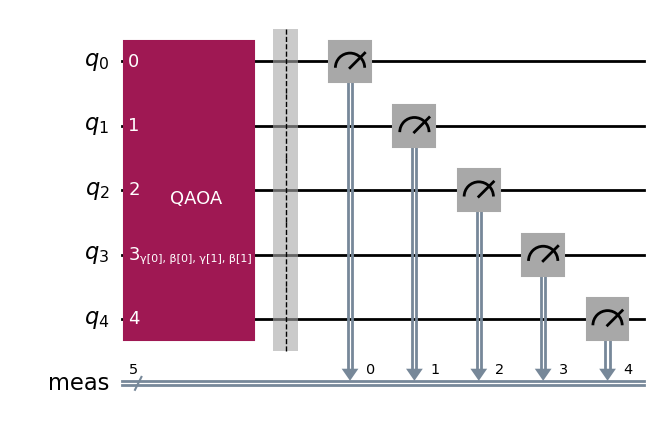

In [23]:
layers = 2
qaoa_circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=layers)
qaoa_circuit.measure_all()
qaoa_circuit.draw("mpl")

QAOA回路を定義したら、Pass Managerに渡してバックエンドのネイティブゲートにトランスパイルします。

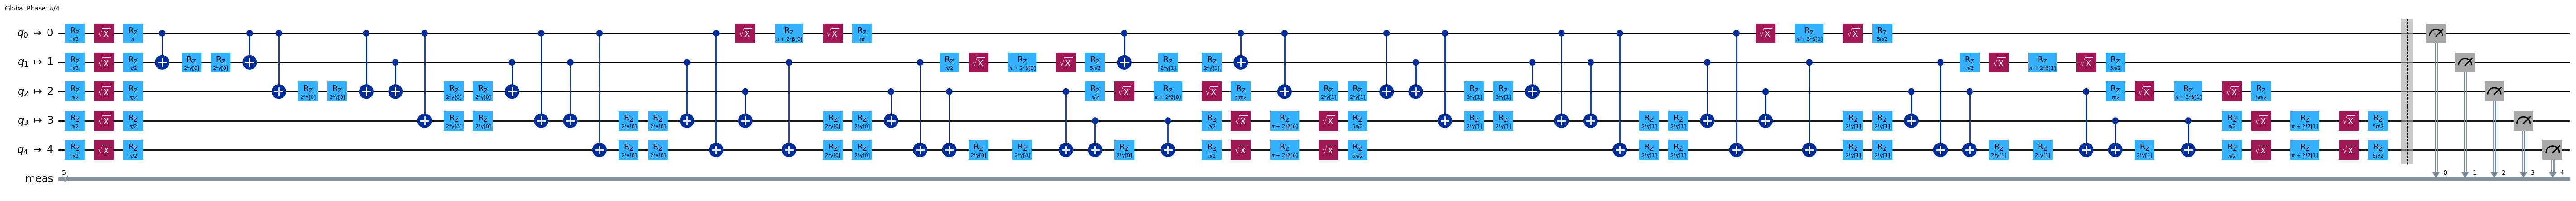

In [25]:
# トランスパイルするためのパスマネージャーを作成

pm = generate_preset_pass_manager(
    optimization_level=3, backend=generic_backend, seed_transpiler=seed
)

qaoa_circuit_transpiled = pm.run(qaoa_circuit)
qaoa_circuit_transpiled.draw("mpl", fold=False, idle_wires=False)

QAOAモデルの初期パラメータを定義します。

In [26]:
init_params = np.zeros(2 * layers)

`scipy` ライブラリを使って最適化手法を定義し、実行します。

In [27]:
objective_func_vals = []


def cost_func_estimator(
    params: list, ansatz: QuantumCircuit, isa_hamiltonian: SparsePauliOp, estimator: Estimator
) -> float:
    """Compute the cost function value using a parameterized ansatz and an estimator for a given Hamiltonian."""
    if isa_hamiltonian.num_qubits != ansatz.num_qubits:
        isa_hamiltonian = isa_hamiltonian.apply_layout(ansatz.layout)
    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])
    results = job.result()[0]
    cost = results.data.evs
    objective_func_vals.append(cost)
    return cost


def train_qaoa(
    params: list,
    circuit: QuantumCircuit,
    hamiltonian: SparsePauliOp,
    backend: QiskitRuntimeService.backend,
) -> tuple:
    """Optimize QAOA parameters using COBYLA and an estimator on a given backend."""
    with Session(backend=backend) as session:
        options = {"simulator": {"seed_simulator": seed}}
        estimator = Estimator(mode=session, options=options)
        estimator.options.default_shots = 100000

        result = minimize(
            cost_func_estimator,
            params,
            args=(circuit, hamiltonian, estimator),
            method="COBYLA",
            options={"maxiter": 200, "rhobeg": 1, "catol": 1e-3, "tol": 0.0001},
        )
    print(result)
    return result, objective_func_vals


result_qaoa, objective_func_vals = train_qaoa(
    init_params, qaoa_circuit_transpiled, cost_hamiltonian, generic_backend
)

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -3.2863771362286376
       x: [ 9.958e-01  1.181e+00  3.710e-02  9.495e-01]
    nfev: 47
   maxcv: 0.0


最適化ルーチンが実行された後、コスト関数がイテレーション数とともにどのように変化したかを確認し、アルゴリズムの収束具合をチェックできます。

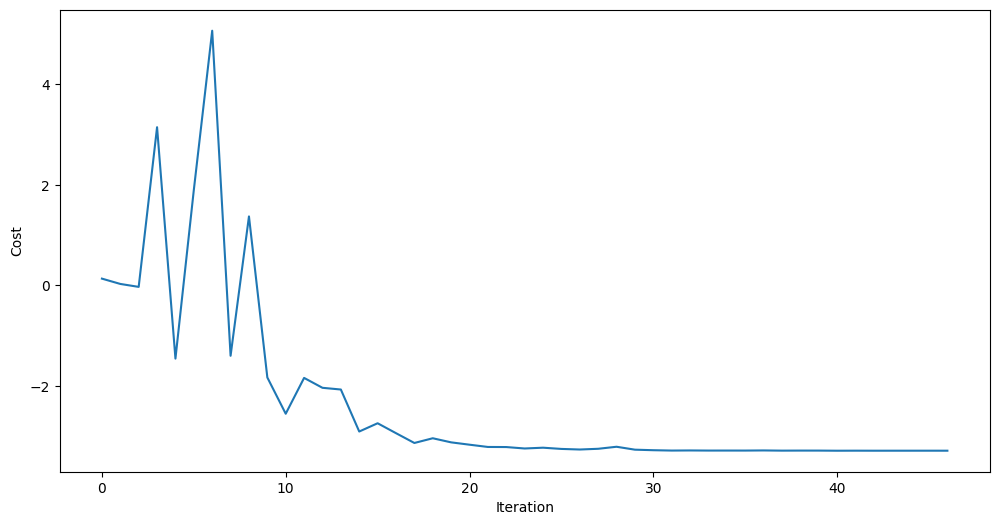

In [28]:

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

すばらしい！ご覧の通り、回路はかなりうまくトレーニングされ、コストハミルトニアンの最小エネルギーに対応する値に収束しています。しかし、これで終わりでしょうか？本当にこれが最小エネルギーであることをどうやって確認できるのでしょうか？同様に、最小エネルギーを見つけたとしても、それはどの基底状態に対応するのでしょうか？つまり、Max-cut 問題の実際の解は何でしょうか？

## 2.4 解の検証 <a id="checking"></a>
Estimator プリミティブを使用して QAOA 回路をトレーニングし、コストハミルトニアンの基底エネルギーを取得した後、Sampler プリミティブを使用して QAOA の最適化されたパラメータで回路を実行することで基底状態を取得できます。

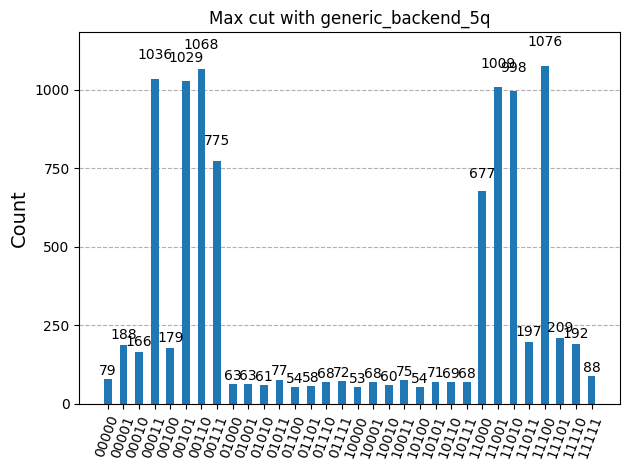

In [30]:
# 結果から最適化されたパラメータを取得
opt_params = result_qaoa.x
SHOTS = 10000


def sample_qaoa(opt_params, circuit, backend):

    # Samplerに回路を提出
    options = {"simulator": {"seed_simulator": seed}}
    sampler = Sampler(mode=backend, options=options)
    job = sampler.run([(circuit, opt_params)], shots=SHOTS)
    results_sampler = job.result()
    counts_list = results_sampler[0].data.meas.get_counts()
    display(plot_histogram(counts_list, title=f"Max cut with {backend.name}"))

    return counts_list


counts_list = sample_qaoa(opt_params, qaoa_circuit_transpiled, generic_backend)

8つの異なる状態が他の状態よりもかなり高い確率となっているようです。これは、8つの異なる基底状態が存在する可能性を示唆しています。しかし、これをどうやって確認できるのでしょうか？幸いなことに、この Max-cut 問題はそれほど大きくないため、まだ解析的に解くことができ、私たちの解が良い近似であるか悪い近似であるかを判断するのに役立ちます。見てみましょう！

Max-cut 問題を解析的に解くには、コストハミルトニアンを対角化することです。これは、問題のサイズがそれほど大きくないために実行が可能です。ただし、この問題の複雑さはノード（量子ビット）の数に指数関数的にスケールするため、ノード数が多くなると問題を扱いきれなくなります。

In [31]:
eigenvalues, eigenvectors = np.linalg.eig(cost_hamiltonian)
ground_energy = min(eigenvalues).real
num_solutions = eigenvalues.tolist().count(ground_energy)
index_solutions = np.where(eigenvalues == ground_energy)[0].tolist()
print(f"The ground energy of the Hamiltonian is {ground_energy}")
print(f"The number of solutions of the problem is {num_solutions}")
print(f"The list of the solutions based on their index is {index_solutions}")

The ground energy of the Hamiltonian is -5.0
The number of solutions of the problem is 8
The list of the solutions based on their index is [3, 5, 6, 7, 24, 25, 26, 28]


素晴らしいですね！8つの解を得られたので、次に後処理を行い、8つの可能な解が私たちが導いた解と一致するか確認しましょう。

In [32]:
def decimal_to_binary(decimal_list, n):
    return [bin(num)[2:].zfill(n) for num in decimal_list]


# 解を量子状態に変換
states_solutions = decimal_to_binary(index_solutions, n)
# 辞書のアイテムをカウントで降順にソート
sorted_states = sorted(counts_list.items(), key=lambda item: item[1], reverse=True)
# 上位の 'num_solutions' エントリを取得
top_states = sorted_states[:num_solutions]
# 上位のエントリから状態のキーのみを抽出
qaoa_ground_states = sorted([state for state, count in top_states])
print(f"The analytical solutions for the Max-cut problem are: {states_solutions}")
print(f"The QAOA ground states solutions for the Max-cut are: {qaoa_ground_states}")

The analytical solutions for the Max-cut problem are: ['00011', '00101', '00110', '00111', '11000', '11001', '11010', '11100']
The QAOA ground states solutions for the Max-cut are: ['00011', '00101', '00110', '00111', '11000', '11001', '11010', '11100']


わあ！私たちは QAOA を使用して Max-cut 問題の正しい解を見つけることに成功しました！

ただし、これらの結果は理想的な量子シミュレータを使用して得られたものであり、実際の量子ハードウェアに存在するノイズや不完全性は考慮されていません。次のセクションでは、ノイズ付き量子シミュレータで QAOA を実行した場合のパフォーマンスを調べ、ノイズが量子アルゴリズムにどのように影響するかを実際に確認します。

# 3. ノイズあり量子シミュレータ <a id="noisy-simulator"></a>

このセクションでは、ノイズのある量子シミュレータで QAOA アルゴリズムを実行します。シミュレータは、実際の量子プロセッサの動作とノイズを模倣することを目的とした有用なツールです。これにより、実際の量子ハードウェアでのパフォーマンスをテストおよび評価が可能で、貴重な量子リソースを消費せずに済みます。さらに、ノイズのあるシミュレータは通常、ローカルマシンで実行されるため、クラウドベースの量子デバイスに関連する潜在的な遅延やキューを回避できるため、実行が速いことが多いです。

しかし、次に進む前に、重要な質問が浮かび上がります。どの量子デバイスを使用すればよいのでしょうか？これは、時には見落とされがちな重要な質問です。以下では、特定の量子アルゴリズムを実行するために最も適切なデバイス（またはシミュレータ）を選択する方法について探ります。

## 3.1 バックエンドの選択 <a id="choosing-backend"></a>

ここでは量子デバイスのノイズを模倣するノイズ付きシミュレータに対応する量子バックエンドを紹介します。

それでは、利用可能なバックエンドを見てみましょう。

In [33]:
real_backends = service.backends()
print(f"The quantum computers available for you are {real_backends}")

The quantum computers available for you are [<IBMBackend('ibm_brisbane')>, <IBMBackend('ibm_sherbrooke')>, <IBMBackend('ibm_torino')>]


オープンプラン（無料）を使用している場合は、`ibm_brisbane`、`ibm_sherbrooke`、および `ibm_torino` のバックエンドが利用可能です。

アクセスできる各バックエンドのノイズ付きシミュレータを作成し、それらにどのゲートがあるかを確認することができます。

<div class="alert alert-block alert-warning">
<b>利用可能なバックエンド</b>

アカウントによって、利用可能なバックエンドが異なる場合があります。可能であれば `ibm_brisbane`、`ibm_sherbrooke`、および `ibm_torino` の3つのバックエンドのみを使用してください。ただし、何らかの理由でこれらが利用できない場合は、3つの異なるバックエンドを自由に使用してください。

In [34]:
# backends=[service.backend("alt_brisbane"),service.backend("alt_kawasaki"),service.backend("alt_torino")]
real_backends = [
    service.backend("ibm_brisbane"),
    service.backend("ibm_sherbrooke"),
    service.backend("ibm_torino"),
]

In [35]:
noisy_fake_backends = []
for backend in real_backends:
    noisy_fake_backends.append(AerSimulator.from_backend(backend, seed_simulator=seed))
print(f"The noisy simulators are {noisy_fake_backends}")

The noisy simulators are [AerSimulator('aer_simulator_from(ibm_brisbane)'
             noise_model=<NoiseModel on ['id', 'x', 'sx', 'reset', 'ecr', 'measure']>), AerSimulator('aer_simulator_from(ibm_sherbrooke)'
             noise_model=<NoiseModel on ['id', 'x', 'sx', 'reset', 'ecr', 'measure']>), AerSimulator('aer_simulator_from(ibm_torino)'
             noise_model=<NoiseModel on ['id', 'x', 'sx', 'reset', 'cz', 'measure']>)]


それでは、回路を様々なバックエンドにトランスパイルし、潜在的なエラーの簡単な分析を行います。

次の演習では、3つのバックエンドに様々な量子回路を適用して蓄積される総エラーをカウントします。[`backend.properties()`](https://quantum.cloud.ibm.com/docs/en/guides/get-qpu-information#dynamic-backend-information)、[`circuit.data`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit)、および [`backend.configuration()`](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.QuantumCircuit) を使用することで、各命令によって引き起こされるさまざまなエラーの推定を行うために必要な情報が提供され、実行することができます。

<a id="exercise_3"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 3: エラーのカウント </b>

**あなたの目標:** 量子回路の総エラーを推定してください。

この3番目の演習では、`accululated_errors` を完成させて、異なるバックエンドで量子回路を実行する際に、すべての命令によって導入される総エラーを推定します。<br>
具体的には、以下のエラーを考慮する必要があります：

- 1量子ビットゲート：バックエンドによっては、これには 'rz'、'x'、または 'sx' が含まれる場合があり、それぞれの命令名にアクセスする必要があります。
- 2量子ビットゲート：バックエンドによっては、'cz'、'cx'、または 'ecr' ゲートが含まれます。各バックエンドで使用されているゲートを特定する必要があります。
- 読み出しエラー：回路がトランスパイルされる物理量子ビット上でのみ、総エラーに最後に加えられる定数エラーとして寄与します。


注意すべきことは、各量子ビットには異なるエラー率があるため、すべての操作を単純にカウントして、IBM Quantum Platform の Compute resources ページに表示される平均エラー値を掛けて計算することはできません。<br>
この近似は近い結果をもたらすかもしれませんが、この演習の目標は、詳細なバックエンド情報にアクセスし、量子ビットごとの特定のエラー率を考慮してより正確な推定を行う方法を学ぶことです。

また、測定ゲートは 1量子ビットゲートとして数えないでください。そのエラーはすでに読み出しエラーに含まれています。

</div>

In [75]:
# 単一および二量子ビットゲートの累積エラーと読み出しエラーを計算する関数を定義


def accumulated_errors(backend: QiskitRuntimeService.backend, circuit: QuantumCircuit) -> list:
    """与えられた回路と特定のバックエンドに対して、累積ゲートエラーと読み出しエラーを計算する"""

    # 初期化
    acc_single_qubit_error = 0
    acc_two_qubit_error = 0
    single_qubit_gate_count = 0
    two_qubit_gate_count = 0
    acc_readout_error = 0

    # 有用な変数を定義
    properties = backend.properties()
    qubit_layout = list(circuit.layout.initial_layout.get_physical_bits().keys())[:n]

    # ---- TODO : Task 3 ---
    # 目標: 以下の量を定義する
    # acc_total_error, acc_two_qubit_error, acc_single_qubit_error, acc_readout_error, single_qubit_gate_count, two_qubit_gate_count

    # TODO `properties.readout_error`を使用して、読み出しエラー（qubit_layoutの量子ビットのみ）を定義
    acc_readout_error=0
    for q in qubit_layout:
        acc_readout_error+=properties.readout_error(q) # TODO
    # TODO `backend.configuration()`を使用して、異なるバックエンドの二量子ビットゲートを定義
    basis_gates = backend.configuration().basis_gates
    print(basis_gates)
    if "ecr" in basis_gates: # TODO
        two_qubit_gate = "ecr"
    elif "cz" in basis_gates: # TODO
        two_qubit_gate = "cz"
    # TODO `circuit.data`の命令をループして、単一および二量子ビットのエラーと単一および二量子ビットゲートのカウントを考慮する
    for instruction in circuit.data:
        gate_name = instruction.operation.name

        if gate_name == "measure":
            continue
        
        qubits = [q._index for q in instruction.qubits]
        if instruction.operation.num_qubits == 1: # TODO 1量子ビットゲートのエラーをカウントして追加
            single_qubit_gate_count += 1
            acc_single_qubit_error += properties.gate_error(gate=gate_name, qubits=qubits)
            
        elif gate_name == two_qubit_gate: # TODO 2量子ビットゲートのエラーをカウントして追加
            two_qubit_gate_count += 1
            acc_two_qubit_error += properties.gate_error(gate=gate_name, qubits=qubits)

    # --- End of TODO ---

    acc_total_error = acc_two_qubit_error + acc_single_qubit_error + acc_readout_error
    results = [
        acc_total_error,
        acc_two_qubit_error,
        acc_single_qubit_error,
        acc_readout_error,
        single_qubit_gate_count,
        two_qubit_gate_count,
    ]
    return results


#accumulated_errors(noisy_fake_backends[0], pm.run(qaoa_circuit))

`errors_and_counts_list[]` を生成して grader に渡しましょう。

In [76]:
qaoa_transpiled_list = []
errors_and_counts_list = []
for noisy_fake_backend in noisy_fake_backends:
    pm = generate_preset_pass_manager(
        backend=noisy_fake_backend,
        optimization_level=3,
        seed_transpiler=seed,
    )
    circuit = pm.run(qaoa_circuit)
    qaoa_transpiled_list.append(circuit)

    errors_and_counts = accumulated_errors(noisy_fake_backend, circuit)
    errors_and_counts_list.append(errors_and_counts)
# 正しいかどうかを確認するために、結果を表示できます
for backend, (
    acc_total_error,
    acc_two_qubit_error,
    acc_single_qubit_error,
    acc_readout_error,
    single_qubit_gate_count,
    two_qubit_gate_count,
) in zip(noisy_fake_backends, errors_and_counts_list):
    print(f"Backend {backend.name}")
    print(f"Accumulated two-qubit error of {two_qubit_gate_count} gates: {acc_two_qubit_error:.3f}")
    print(
        f"Accumulated one-qubit error of {single_qubit_gate_count} gates: {acc_single_qubit_error:.3f}"
    )
    print(f"Accumulated readout error: {acc_readout_error:.3f}")
    print(f"Accumulated total error: {acc_total_error:.3f}\n")

['ecr', 'id', 'rz', 'sx', 'x', 'break_loop', 'continue_loop', 'delay', 'for_loop', 'if_else', 'initialize', 'kraus', 'qerror_loc', 'quantum_channel', 'reset', 'roerror', 'save_amplitudes', 'save_amplitudes_sq', 'save_clifford', 'save_density_matrix', 'save_expval', 'save_expval_var', 'save_matrix_product_state', 'save_probabilities', 'save_probabilities_dict', 'save_stabilizer', 'save_state', 'save_statevector', 'save_statevector_dict', 'save_superop', 'save_unitary', 'set_density_matrix', 'set_matrix_product_state', 'set_stabilizer', 'set_statevector', 'set_superop', 'set_unitary', 'superop', 'switch_case', 'while_loop']
['ecr', 'id', 'rz', 'sx', 'x', 'break_loop', 'continue_loop', 'delay', 'for_loop', 'if_else', 'initialize', 'kraus', 'qerror_loc', 'quantum_channel', 'reset', 'roerror', 'save_amplitudes', 'save_amplitudes_sq', 'save_clifford', 'save_density_matrix', 'save_expval', 'save_expval_var', 'save_matrix_product_state', 'save_probabilities', 'save_probabilities_dict', 'save_s

結果をプロットしましょう。

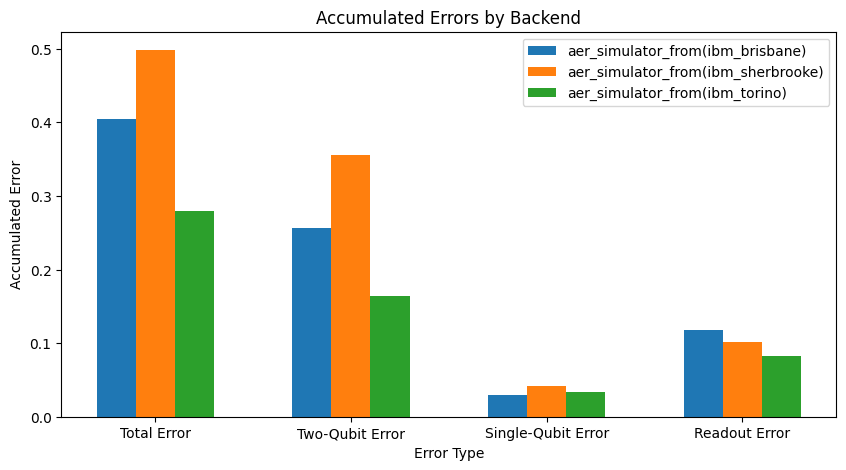

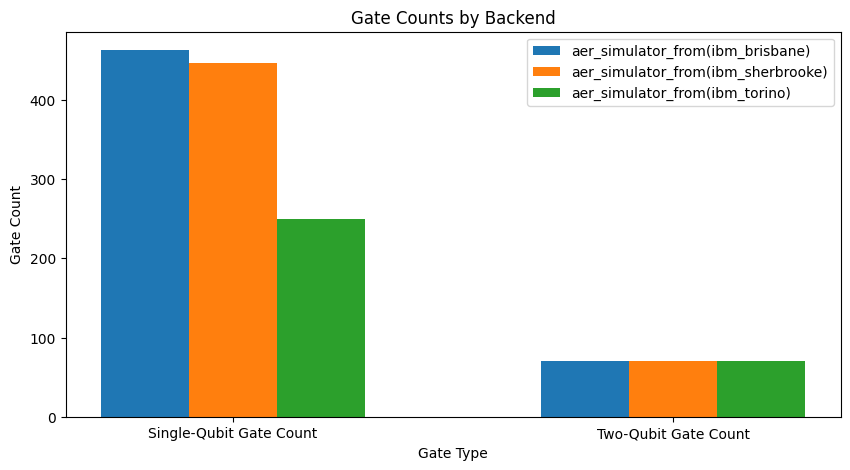

In [77]:
plot_backend_errors_and_counts(noisy_fake_backends, errors_and_counts_list)

In [78]:
# 次のコードを実行して、課題を提出してください
grade_lab2_ex3(accumulated_errors)

['ecr', 'id', 'rz', 'sx', 'x']
['ecr', 'id', 'rz', 'sx', 'x']
['cz', 'id', 'rz', 'sx', 'x']
Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.



`ibm_torino` の方が他のノイズのあるバックエンドよりも蓄積エラーが小さいことがわかりました。これらの結果を実際に活用し、様々なバックエンドで QAOA アルゴリズム全体を実行してみましょう！


<div class="alert alert-block alert-warning">
<b>注意: 2分必要です スキップしないこと！</b>

以下のコードを実行すると、約2分かかり、このノートブックがその間ブロックされます。<br>

</div>

In [ ]:
opt_params_list = []
counts_list_backends = []
for noisy_fake_backend, circuit in zip(noisy_fake_backends[:1], qaoa_transpiled_list[:1]):
    result_backend, _ = train_qaoa(init_params, circuit, cost_hamiltonian, noisy_fake_backend)
    opt_params = result_backend.x
    opt_params_list.append(opt_params)
    counts_list_backend = sample_qaoa(opt_params, circuit, noisy_fake_backend)
    counts_list_backends.append(counts_list_backend)

<div class="alert alert-block alert-warning">
<b>警告: 8分必要です</b>

以下のコードを実行すると、約8分かかり、このノートブックがその間ブロックされます

このセルをスキップしたい場合は、[セクション4](#transpiler)に直接進んでください。

</div>

In [ ]:
for noisy_fake_backend, circuit in zip(noisy_fake_backends[1:], qaoa_transpiled_list[1:]):
    result_backend, _ = train_qaoa(init_params, circuit, cost_hamiltonian, noisy_fake_backend)
    opt_params = result_backend.x
    opt_params_list.append(opt_params)
    counts_list_backend = sample_qaoa(opt_params, circuit, noisy_fake_backend)
    counts_list_backends.append(counts_list_backend)

3つのバックエンドは正しい結果を出しているようです。ただし、`ibm_torino` バックエンドは、解ではない状態を測定する確率が低いため、ノイズレベルが低いようです。

ここで、バックエンドのパフォーマンスを比較するために、正しい解を測定する確率に基づいたメトリクスを定義できます。3つのバックエンドはすべて同じ8つの解を最も可能性の高い結果として予測しているため、このメトリクスはどのバックエンドがより信頼性が高いかを識別するのに役立ちます。

In [ ]:
for noisy_fake_backend, counts_list_backend in zip(noisy_fake_backends, counts_list_backends):
    solutions_counts = [counts_list_backend[key] for key in states_solutions]
    print(
        f"Probability of measuring a solution for {noisy_fake_backend.name} is {float(sum(solutions_counts)/SHOTS)}"
    )

予想通り、`ibm_torino` は解を測定する確率が最も高いことがわかりました。これは、以前のエラー推定分析が、どのバックエンドが最小のエラーでアルゴリズムを実行するかを予測するのに正しかったことを確認しています。ノイズの影響をさらに理解するために、これらの確率を `GenericBackend` のものと比較することもできます。これは理想的なノイズのないシナリオをシミュレートします。

In [ ]:
solutions_counts_noiseless = [counts_list[key] for key in states_solutions]
print(
    f"Probability of measuring a solution for {generic_backend.name} is {float(sum(solutions_counts_noiseless)/SHOTS)}"
)

ノイズのない `GenericBackend` で正しい解を測定する確率は、予想通り、ノイズのあるバックエンドよりも高いです。ただし、その差はそれほど大きくありません。これは重要な点を強調しています。現在のノイズのある量子コンピュータでも、慎重でスマートな回路設計と適切なツールを使用すれば、多くの問題を十分な精度で解決できることを示しています！

## 3.2 NEAT を使用したエラー推定 <a id="neat"></a>

先ほど行ったエラー推定は、デバイスのノイズレベルを大まかに把握するための良い近似です。その点で、Qiskit は別の選択肢を提供しています。それが Noisy Estimator Analyzer Tool (NEAT) です。NEAT は、特に Estimator プリミティブを使用する際の量子推定タスクのパフォーマンスを理解し予測するために設計された関数です。qiskit-aer シミュレータを活用して、理想的な（ノイズのない）シミュレーションとノイズのあるシミュレーションの両方を実行します。

NEAT の重要な機能の一つは、Clifford 回路を効率的にシミュレートできることです。非 Clifford 回路の場合、NEAT は自動的にそれらを最も近い Clifford 回路と等価の回路に変換し、量子状態を近似します。これにより、実際の量子ハードウェアで実行する前に、量子回路のノイズ分析を行うのに特に便利です。ただし、この近似には制限があり、Clifford 等価回路は非 Clifford 回路の振る舞いを完全に再現できないため、特定のケースではシミュレーションの精度が失われる可能性があります。

実践的な観点から、NEAT を使用する一つの方法は、ノイズのあるシナリオとノイズのないシナリオで量子回路をシミュレートし、期待値が理想的な（ノイズのない）ケースで正確に 1 になる可観測量を測定することです。この設定では、ノイズのあるシミュレーション上で 1 からのズレは回路に対するノイズの影響を直接反映します。可観測量が要件を満たすことを保証する簡単な方法は、次のように選択することです：

$$
\hat{O}=|\psi\rangle\langle \psi|, \quad \textrm{したがって} \quad \langle \psi |\hat{O}|\psi \rangle=1, 
$$

ここで $|\psi\rangle$ はシミュレートしたい回路によって生成される量子状態です。

それでは、NEAT を使用して異なるノイズ付きバックエンドのパフォーマンスを確認してみましょう！

In [79]:
results = []
for backend, opt_params in zip(noisy_fake_backends, opt_params_list):
    print(f"\nRunning on backend: {backend.name}")

    # 最適なパラメータを使用してQAOA回路を準備
    qaoa_neat = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=layers)
    qc = qaoa_neat.assign_parameters(opt_params)

    # 回路をトランスパイル
    qc_transpiled = generate_preset_pass_manager(
        optimization_level=3,
        basis_gates=backend.configuration().basis_gates[:n],
        seed_transpiler=seed,
    ).run(qc)
    # クリフォード化のためにコストハミルトニアンをオブザーバブルとして使用
    obs = cost_hamiltonian
    analyzer = Neat(backend)
    clifford_pub = analyzer.to_clifford([(qc_transpiled, obs)])[0]

    # クリフォード回路からオブザーバブルを構築
    state_clifford = Statevector.from_instruction(clifford_pub.circuit)
    obs_clifford = SparsePauliOp.from_operator(Operator(DensityMatrix(state_clifford).data))

    # レイアウトを適用
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1, seed_transpiler=seed)
    isa_qc = pm.run(clifford_pub.circuit)
    isa_obs = obs_clifford.apply_layout(isa_qc.layout)

    # pubsを準備してシミュレート
    pubs = [(isa_qc, isa_obs)]
    result_noiseless = (
        analyzer.ideal_sim(pubs, cliffordize=True, seed_simulator=seed)._pub_results[0].vals
    )
    noisy_results = (
        analyzer.noisy_sim(pubs, cliffordize=True, seed_simulator=seed)._pub_results[0].vals
    )

    # 結果を保存して表示
    results.append({"backend": backend.name, "noiseless": result_noiseless, "noisy": noisy_results})
    print(f"Ideal results on {backend.name}:\n{result_noiseless:.3f}")
    print(f"Noisy results on {backend.name}:\n{noisy_results:.3f}")

NameError: name 'opt_params_list' is not defined

NEAT を使用すると、ノイズのあるシミュレーションでの期待値が理想的な値 1 からどのように逸脱するかを観察できます。これは、[セクション 3.1]((#choosing-backend)) で行ったノイズ分析と一致しています。

ただし、前述のように、ここでは量子回路の Clifford 化バージョンを分析していることに注意する必要があります。つまり、回路が Clifford 群に属するように一部のゲートが変換されています。その結果、変換された回路は類似していますが、正確に同じ量子状態を生成するわけではありません。これは、Neat が特定のバックエンドで回路がどれだけノイズを蓄積するかの有用な近似を提供しますが、正確な予測や保証を提供しないことを意味します。これは重要ですので覚えておいてください！

# 4. トランスパイラ <a id="transpiler"></a>

トランスパイラは、実際の量子ハードウェア上での量子回路の実行において最も重要で有用なツールの一つです。これは、抽象的で理想化された量子回路と、実際の量子デバイス上での物理的な実装との間の橋渡しをします。回路を設計する際、通常は仮想量子ビットと理想的なゲートを使用し、ハードウェア特有の制限を考慮しません。トランスパイラは、この高レベルの回路を、デバイス上で利用可能な物理量子ビットゲート操作のみを使用して実装できるバージョンに変換します。

例えば、回路に仮想量子ビット 0 と 1 の間の CNOT ゲートが含まれているとします。実際のデバイスでは、これらの2つの量子ビットは直接接続されていないかもしれません。そのような場合、トランスパイラは一連の SWAP ゲートを挿入して、量子状態を物理的に隣接する量子ビットに移動し、CNOT 操作を可能にします。または、トランスパイラはより効率的な量子ビットマッピングを見つけ、仮想量子ビット 0 と 1 を物理量子ビット 3 と 4 に再割り当てし、追加の SWAP ゲートを必要としないようにすることもあります。

ここまで、`generate_preset_pass_manager` を実行する際にトランスパイラを暗黙的に使用してきました。しかし、ここからはトランスパイラに焦点を当て、よりよく理解し、量子回路の設計を最大限に活用できるようにします。

## 4.1 2量子ビットゲートの最小化 <a id="min-two-qubit"></a>

量子トランスパイラの最も重要なタスクの一つは、量子回路を実行するための最適な量子ビットレイアウトを決定することです。これには、回路の仮想量子ビットとデバイスの物理量子ビットとの間の最適なマッピングを見つけることが含まれます。そのためには、いくつかの点を考慮する必要があります。

はじめに、トランスパイラは回路内のすべての2量子ビットゲートをチェックし、選択された物理量子ビットに対して操作が可能であるように接続されていることを確認する必要があります。これにより、追加で必要な SWAP ゲートを減らすことができます。そのためには、物理量子ビットがどのように接続されているかを示すカップリングマップを調べる必要があります。

まず、量子回路を量子コンピュータのレイアウトにトランスパイルし、エラーの主な原因となる2量子ビットゲートの数を最小限に抑えるようにします。

特に、[セクション 3.1](#choosing-backend) で示したように、2量子ビットゲートエラーが総蓄積エラーの大部分を占める `ibm_brisbane` バックエンドを考えてみましょう。

In [ ]:
# `ibm_brisbase` バックエンドを選択
num_backend = 0
noisy_fake_backend = noisy_fake_backends[num_backend]

pm = generate_preset_pass_manager(
    backend=noisy_fake_backend,
    optimization_level=3,
    seed_transpiler=seed,
    layout_method="sabre",
)
circuit_transpiled = pm.run(qaoa_circuit)


def two_qubit_gate_errors_per_circuit_layout(
    circuit: QuantumCircuit, backend: QiskitRuntimeService.backend
) -> tuple:
    """与えられた回路レイアウトに対して、累積二量子ビットゲートエラーと関連するメトリックを計算する"""
    pair_list = []
    error_pair_list = []
    error_acc_pair_list = []
    two_qubit_gate_count = 0
    properties = backend.properties()
    if "ecr" in (backend.configuration().basis_gates):
        two_qubit_gate = "ecr"
    elif "cz" in (backend.configuration().basis_gates):
        two_qubit_gate = "cz"
    for instruction in circuit.data:
        if instruction.operation.num_qubits == 2:
            two_qubit_gate_count += 1
            pair = [instruction.qubits[0]._index, instruction.qubits[1]._index]
            error_pair = properties.gate_error(gate=two_qubit_gate, qubits=pair)
            if pair not in (pair_list):
                pair_list.append(pair)
                error_pair_list.append(error_pair)
                error_acc_pair_list.append(error_pair)
            else:
                pos = pair_list.index(pair)
                error_acc_pair_list[pos] += error_pair

    acc_two_qubit_error = sum(error_acc_pair_list)
    return (
        acc_two_qubit_error,
        two_qubit_gate_count,
        pair_list,
        error_pair_list,
        error_acc_pair_list,
    )


(
    acc_two_qubit_error,
    two_qubit_gate_count,
    pair_list,
    error_pair_list,
    error_acc_pair_list,
) = two_qubit_gate_errors_per_circuit_layout(circuit_transpiled, noisy_fake_backend)
two_qubit_ops_list = [int(a / b) for a, b in zip(error_acc_pair_list, error_pair_list)]
# We print the results
print(f"The pairs of qubits that need to perform two-qubit operations are:\n {pair_list}")
print(
    f"The errors introduced by each of the two-qubit operations are:\n {[round(err,3) for err in error_pair_list]}"
)
print(

    f"The accumulated errors introduced by each of the two-qubit operations are:\n {[round(err,3) for err in error_acc_pair_list]}"
)
print(f"The repetitions of each one of the two-qubit operations is:\n {two_qubit_ops_list}")
print(f"The number of two-qubit operations in total:\n {two_qubit_gate_count}")
print(f"The total accumulated error by two-qubit operations is:\n {acc_two_qubit_error:.3f}")

## 4.2 最適なレイアウトを見つける <a id="opt-layout"></a>

次に、トランスパイラは接続制約を満たす「最適な」物理量子ビットを選択する必要があります。しかし、この文脈で「最適な量子ビット」を定義することは、コヒーレンス時間（$T_1$、$T_2$）、単一量子ビットゲートエラー率、読み出しエラー、2量子ビットゲートエラー率などの複数のハードウェア固有のメトリクスに依存するため、困難なタスクです。これらすべてのメトリクスを同時に最適化することは簡単ではなく、多くの場合トレードオフが伴います。

この演習では、問題を簡略化するために2つの基準に焦点を当てます：
1. 選択された量子ビットはトランスパイラによって与えられた必要な接続性を満たす
2. 2量子ビットゲートエラー率が最も低い量子ビットを選択する

[セクション 3.1](#choosing-backend) で説明したように、2量子ビットゲートエラーは多くの量子デバイスにおいて通常、主要なノイズ源となります。

この演習では、2量子ビットゲートの操作による総蓄積エラーが小さい量子ビット構成（レイアウト）を探すことです。ただし、これは簡単すぎるかもしれませんので、難易度を上げて、2量子ビットゲート操作の総蓄積エラーが小さいすべての可能なレイアウトを探してみましょう。

以下のグラフを構築することで、可能な構成を視覚化できるだけでなく、望ましい条件を満たすすべてのレイアウトを見つけるのにも役立ちます。

In [ ]:
# エッジの重みである2量子ビットゲートエラーを含むバックエンドの接続制約を持つグラフを構築
graph = rx.PyDiGraph()
graph.add_nodes_from(np.arange(0, noisy_fake_backend.num_qubits, 1))
two_qubit_gate = "ecr"
graph.add_edges_from(
    [
        (
            edge[0],
            edge[1],
            noisy_fake_backend.properties().gate_error(
                gate=two_qubit_gate, qubits=(edge[0], edge[1])
            ),
        )
        for edge in noisy_fake_backend.coupling_map
    ]
)
draw_graph(graph, node_size=150, with_labels=True, width=1)

また、`pair_list` にあるゲートを可能にする接続性を持つレイアウトを探す必要があることに注意してください。これは、`logical_pair_list` を使うことで、より解釈しやすいリストに変換できます。

In [ ]:
def remap_nodes(original_labels: list, edge_list: list[list]) -> list[list[int]]:
    """Remap node labels to a new sequence starting from 0 based on their order in original_labels."""
    label_mapping = {label: idx for idx, label in enumerate(original_labels)}
    remapped = [[label_mapping[src], label_mapping[dst]] for src, dst in edge_list]
    return remapped


layout_list = list(circuit_transpiled.layout.initial_layout.get_physical_bits().keys())[:5]
logical_pair_list = remap_nodes(layout_list, pair_list)
print(f"Physical qubit layout list:\n {layout_list}")
print(f"\nOriginal two-qubit gates list:\n {pair_list}")
print(f"\nRemapped two-qubit gates list (in logical qubits):\n {logical_pair_list}")

<a id="exercise_4"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 4: 良いマッピング</b>

**あなたの目標:** すべての良い量子ビットレイアウトを見つける。

この4番目の演習では、上記のトランスパイラによるレイアウトの2量子ビットゲートの総蓄積エラーよりも小さいすべての可能な量子ビットレイアウトを見つけることが求められます。この値は変数 `acc_two_qubit_error` に格納されています。この問題はグラフ問題として再定式化できます。すなわち、上記のグラフの中で、エッジの重みの合計が指定された閾値未満であり、かつ `logical_pair_list` にある接続性と同じ接続性を持つすべての経路を見つける必要があります。

</div>

<div class="alert alert-block alert-warning">
<b>警告：総当たりで解こうとしないでください！</b>

総当たり法で解こうとすると、経路の数が膨大なため、計算に何時間もかかる可能性があります。その代わりに、`logical_pair_list` と同じ接続性を持つ経路（これは100未満です）だけに検索を制限することで、計算時間は1秒未満になります。
</div>

</div>

<div class="alert alert-info">
<details>
    <summary> <b>ヒント</b> 💡: (クリックすると展開されます)</summary>

この演習のために提案されたワークフローは次のとおりです。

1. グラフ内の各ノードから開始し、1ステップずつ拡張することで経路を反復的に構築します。

2. 各ステップで、`logical_pair_list` を使用して、現在のパスからどのノードを拡張するかを決定します。

3. 拡張元のノードが制御量子ビットに対応するか、ターゲット量子ビットに対応するかに応じて、隣接ノードへのアクセス方法を選択します。

    3.1 制御量子ビットの場合は、有向エッジ（`graph.neighbors`）を使用します。

    3.2 ターゲット量子ビットの場合は、無向エッジ（`graph.neighbors_undirected`）を使用します。

4. 各経路を拡張する際に、エッジの重み（`graph.get_edge_data(edge_1,edge_2)`）に対応する `two_qubit_ops_list` の値を掛け算することで、累積重みを計算します。無向隣接ノードを使用している場合は、`graph.get_edge_data(edge_2,edge_1)` を使用する必要があります。

5. 経路が完成したら、すなわち `two_qubit_ops_list` の長さに達したら、総重みが閾値未満の経路のみを保持するように確認します。

</details>

</div>

次の演習では、コード内で使われている以下の関数が有用かもしれません:[rx.PyDiGraph.neighbors](https://www.rustworkx.org/dev/apiref/rustworkx.PyDiGraph.neighbors.html), [rx.PyDiGraph.neighbors_undirected](https://www.rustworkx.org/dev/apiref/rustworkx.PyDiGraph.neighbors_undirected.html), [rx.PyDiGraph.has_edge](https://www.rustworkx.org/apiref/rustworkx.PyDiGraph.has_edge.html)

また、[rx.PyDiGraph.get_edge_data](https://www.rustworkx.org/apiref/rustworkx.PyDiGraph.get_edge_data.html) は特に役立つかもしれません。これは、グラフ内の各相互作用に関連付けられた2量子ビットゲートエラーを取得することができます。

In [ ]:
def find_paths_with_weight_sum_below_threshold(
    graph: rx.PyDiGraph,
    threshold: float,
    two_qubit_ops_list: list[int],
    logical_pair_list: list[list[int]],
) -> tuple[list[list[int]], list[float]]:
    """重み付きの合計が指定されたしきい値を下回るグラフを通るすべての有効なパスを見つける"""
    valid_paths = []
    valid_weights = []

    # Task 4 ---
    # 目標: グラフを通るすべての有効なパスを見つけ、パスの重み付き合計が指定されたしきい値を下回るようにする

    # グラフのすべての可能な開始ノードを反復処理
    for start_node in range(graph.num_nodes()):
        # 現在のノードから始まる単一ノードパスでパスのリストを初期化
        paths = [[start_node]]
        # 各パスの対応する重みを初期化（0から始まる）
        weights = [0]
        # 2量子ビット操作のシーケンスの各ステップを反復処理
        for i in range(len(two_qubit_ops_list)):
            new_paths = []    
            new_weights = []  
            # 現在のパスとその重みをそれぞれ確認
            for path, weight in zip(paths, weights):
                # 現在のパスで次の論理操作に関与するノードを決定し、そこから拡張できるようにします
                # logical_pair_listを使用して、パス内のどのノードから拡張するかを決定します
                if logical_pair_list[i][0] < logical_pair_list[i][1]:
                    index_of_expanding_node = logical_pair_list[i][0] # control qubit
                    node_to_expand_from = path[index_of_expanding_node]
                    # node_to_expand_fromの隣接ノードをすべて探索
                    for neighbor in graph.neighbors(node_to_expand_from):
                        # ノードを再訪せず、エッジが存在することを確認
                        if neighbor not in path and graph.has_edge(node_to_expand_from, neighbor):
                            # エッジの重みを計算し、2量子ビット操作のリストにあるゲートが適用される回数でスケーリングします
                            
                            #### TODO ####
                            
                            edge_weight = 
                            
                            #### End of TODO ####
                            
                            # パスを拡張し、重みを更新
                            new_paths.append(path + [neighbor])
                            new_weights.append(weight + edge_weight)
                else:
                    index_of_expanding_node = logical_pair_list[i][1] # target qubit
                    node_to_expand_from = path[index_of_expanding_node]
                    # node_to_expand_fromの無向隣接ノードをすべて探索
                    for neighbor in graph.neighbors_undirected(node_to_expand_from):
                        # ノードを再訪せず、エッジが存在することを確認
                        if neighbor not in path and graph.has_edge(neighbor, node_to_expand_from):
                            # エッジの重みを計算し、2量子ビット操作のリストにあるゲートが適用される回数でスケーリングします
                            
                            #### TODO ####
                            
                            edge_weight = 
                            
                            #### End of TODO ####
                            
                            # パスを拡張し、重みを更新
                            new_paths.append(path + [neighbor])
                            new_weights.append(weight + edge_weight)
            # 次の反復のためにパスと重みを更新
            paths = new_paths
            weights = new_weights

        # すべての可能なパスを構築した後、しきい値以下のパスをフィルタリング
        for path, weight in zip(paths, weights):

            #### TODO: `if`の条件を完成させてください ####
            
            if( ): 
                valid_paths.append(path)
                valid_weights.append(weight)

            #### End of TODO ####
            
    # --- End of TODO ---

    return valid_paths, valid_weights


threshold = acc_two_qubit_error

valid_paths, valid_weights = find_paths_with_weight_sum_below_threshold(
    graph, threshold, two_qubit_ops_list, logical_pair_list
)
# メモ: 小さいエラーを持つ他のパスがない可能性があります
if valid_weights:
    minimum_weight_index = valid_weights.index(min(valid_weights))
    opt_layout = valid_paths[minimum_weight_index]
else:
    minimum_weight_index = None
    opt_layout = layout_list
print(f"We found {len(valid_paths)} valid paths")

In [ ]:
init_layout = Layout({q: phys for q, phys in zip(qaoa_circuit.qubits, opt_layout)})
pm = generate_preset_pass_manager(
    backend=noisy_fake_backend,
    optimization_level=3,
    seed_transpiler=seed,
    initial_layout=init_layout,
    layout_method="sabre",
)

circuit_opt = pm.run(qaoa_circuit)

(
    acc_total_error_opt,
    two_qubit_gate_count,
    pair_list,
    error_pair_list,
    error_acc_pair_list,
) = two_qubit_gate_errors_per_circuit_layout(circuit_opt, noisy_fake_backend)

print(
    f"The path with smaller errors in its two-qubit gates is: {opt_layout} \n",
    f"With total accumulated error of {acc_total_error_opt:.3f}",
)

In [ ]:
# 次のコードを実行して、課題を提出してください

grade_lab2_ex4(find_paths_with_weight_sum_below_threshold)

よくやりました。これで、一番複雑な部分は終わりです。見つかった組み合わせはすべて、単純なしきい値よりも優れています。

量子ビットのレイアウトを最適化することで、2量子ビットゲートからの蓄積エラーを大幅に削減できることがわかりました。しかし、実際のハードウェアで量子回路を実行するたびにこれを手動で行わねばいけない状況を想像できますか？非常に面倒ですよね？でも心配しないでください。トランスパイラがこのタスクを代わりに処理してくれます。提供されている `layout_methods` の一つを使用することで、トランスパイラは回路の接続性の要件を満たしながら、2量子ビットゲートの数を最小限に抑えるような量子ビットのレイアウトを賢く選択します。

とりわけ、`sabre` メソッドを使用します。これは、SWAP ゲートの数を最小限に抑えることを目的とした確率的手法です。これを最大限に活用するために、トランスパイラのシードをスイープします。これにより、複数のレイアウト構成を探索し、2量子ビットエラー率を最小化したものを選択できます。ここでは、回路の深さや2量子ビットゲートの数、読み出しエラーなど、使用したい任意のメトリクスを最小化することもできます。

<a id="exercise_5"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 5: ベストなマッピング Mapping </b> 

**あなたの目標:** トランスパイラを使用して最適なレイアウトを見つけてください。

この5番目の演習では、`sabre` `layout_method` を使用して、2量子ビットゲートの蓄積エラーが最も低いレイアウトを特定することが求められます。<br>
そのためには、`seed_transpiler` の値を 0 から 500 までスイープし、`generate_preset_pass_manager`を`optimization_level=3`で呼び出して最適なレイアウトを選択してください。2量子ビットゲートの蓄積エラーと2量子ビットゲートの数をカウントは`two_qubit_gate_errors_per_circuit_layout` 関数を使えばよいことを覚えておいてください。


In [ ]:
def finding_best_seed(
    circuit: QuantumCircuit, backend: QiskitRuntimeService.backend
) -> tuple[QuantumCircuit, int, float, int]:
    """与えられた回路とバックエンドに対して、2量子ビットゲートエラーを最小化するトランスパイラシードを見つける"""

    # 最小蓄積エラーを初期化
    min_err_acc_seed_loop = 100
    circuit_opt_best_seed = None
    # 最初に500個のシードをループして回路をトランスパイルする
    for seed_transpiler in range(0, 500):
        pm = generate_preset_pass_manager(
            backend=backend,
            optimization_level=3,
            seed_transpiler=seed_transpiler,
            layout_method="sabre",
        )
        circuit_opt_seed = pm.run([circuit])[0]
        # ---- TODO : Task 5 ---
        # 目標: 0から500までループして、与えられた回路とバックエンドに対して2量子ビットゲートエラーを最小化するトランスパイラシードを見つける

        # TODO `two_qubit_gate_errors_per_circuit_layout`関数を使用して、トランスパイルされた回路のエラーをカウントしてください

        # TODO 上記でカウントされたエラーがmin_err_acc_seed_loopより小さいかどうかを確認してください。もしそうなら、この関数が返す変数に割り当ててください。

        # --- End of TODO ---

    return (
        circuit_opt_best_seed,
        best_seed_transpiler,
        min_err_acc_seed_loop,
        two_qubit_gate_count_seed_loop,
    )

In [ ]:
(
    circuit_opt_seed_loop,
    best_seed_transpiler,
    min_err_acc_seed_loop,
    two_qubit_gate_count_seed_loop,
) = finding_best_seed(qaoa_circuit, noisy_fake_backend)

best_layout = list(circuit_opt_seed_loop.layout.initial_layout.get_physical_bits().keys())[:n]
print(f"Best transpiler seed: {best_seed_transpiler}")
print(f"Minimum accumulated two-qubit gate error: {min_err_acc_seed_loop:.3f}")
print(f"Two-qubit gate count for best seed: {two_qubit_gate_count_seed_loop}")
print(f"Best layout (first n logical qubits mapped to physical qubits):\n {best_layout}")

In [ ]:
# 次のコードを実行して、課題を提出してください

grade_lab2_ex5(finding_best_seed)

次に、これらの回路で QAOA 回路をサンプリングし、優れたトランスパイルの重要性を確認します。

<div class="alert alert-block alert-warning">
<b>警告: 5分かかります</b>


以下のコードを実行すると、約5分かかり、このノートブックがその間ブロックされます。スキップして次のセルに進むこともできます。
</div>

In [ ]:
counts_list_transpiled_circuits = []
circuit_transpiled_list = [circuit_transpiled, circuit_opt_seed_loop]
opt_params_list_transpiled_circuits = []
for circuit in circuit_transpiled_list:
    result_backend, _ = train_qaoa(init_params, circuit, cost_hamiltonian, noisy_fake_backend)
    opt_params = result_backend.x
    opt_params_list_transpiled_circuits.append(opt_params)
    counts_list_transpiled_circuit = sample_qaoa(opt_params, circuit, noisy_fake_backend)
    counts_list_transpiled_circuits.append(counts_list_transpiled_circuits)
    solutions_counts = [counts_list_transpiled_circuit[key] for key in states_solutions]
    print(f"Probability of measuring a solution for is {float(sum(solutions_counts)/SHOTS)}")

以降では、`sabre` レイアウトメソッドを使用し、2量子ビットゲートの数や深さ、蓄積エラーなど特定のメトリクスを最小化するために異なるシードをループして、パフォーマンスを最大化することを忘れないでください。

このセクションでは、トランスパイラが実際のハードウェアで実行される量子回路を準備する上で重要なステップであることを確認しました。デバイスは様々なレイアウトとゲートセットを持つため、優れたトランスパイラは、量子回路の深さやエラー率を低く保ちながら、ハードウェアに適合するように回路を適応させるのに役立ちます。こうすることで量子アルゴリズムのパフォーマンスを向上させることができます。

# 5. エラー緩和 (EM: Error Mitigation)<a id="em"></a>

量子コンピュータの不可避なノイズに対処するための研究分野の一つが、**エラー緩和 (EM: Error Mitigation)** です。EMは、複雑なエラー訂正コードや追加の量子ビットを必要とせずに、ノイズの影響を減らすために設計された一連のインテリジェントな手法です。今日の量子ハードウェアではリソースは依然として限られています。EMは、エラーが発生したときにそれを修正するのではなく、ループの繰り返し、キャリブレーションベースの調整、および古典的な後処理などの戦略を駆使して最終結果の品質を向上させ、量子アルゴリズムのパフォーマンスを改善します。

このアプローチは、現在のデバイスにとって特に価値があります。現在のデバイスは小規模から中規模であり固有のノイズを持っています。完全な誤り耐性を持つ量子コンピューティングはまだ手の届かないところにありますが、EMは現在持っているデバイスを最大限に活用する実用的な方法を提供します。

- Variational Quantum Eigensolver (VQE)
- Quantum Approximate Optimization Algorithm (QAOA)
- 量子機械学習モデル

これらのアルゴリズムは特にノイズに敏感であり、EM はその信頼性と精度を大幅に向上させることができます。

目を見張るべきことに、EMはすべての不完全性を排除するわけではありませんが、結果を十分に洗練させて有用で実行可能なものにします。これは、ノイズのある量子結果と意味のある洞察とのギャップを狭めるためのツールであり、大規模なエラー訂正マシンが現実になる前でも実用的な量子アプリケーションへの道を開きます。

エラー緩和 (EM) にはいくつかの確立された手法があり、それぞれが量子計算における異なるタイプのノイズや不完全性に対処するように調整されています。

広く使用されている手法の一つが、Zero Noise Extrapolation (ZNE) です。このアプローチでは、意図的にノイズレベルを増加させた状態で同じ量子回路を複数回実行します。その後、数学的な外挿技術を適用して、ノイズがない場合の結果を推定します（[Temme et al. in 2017](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.119.180509)）。


## 5.1 Zero Noise Extrapolation (ZNE) <a id="zne"></a>

ZNE は、追加の量子ビットや完全なエラー訂正を必要とせずに、量子回路のノイズの影響を減らすために設計された強力な量子エラー緩和手法です。このプロセスは、ノイズ増幅、さまざまなノイズレベルでの実行、およびゼロノイズ限界への古典的外挿の3つの重要なステージで構成されています。


### ノイズ増幅

最初のステージであるノイズ増幅は　ZNE の心臓部です。アイデアは、通常よりも多くのノイズを持つバージョンで量子回路を実行することですが、制御可能で可逆的な方法で行います。ノイズが増加するにつれて出力がどのように変化するかを比較することで、ノイズがまったくない場合の結果を推測することが可能になります。これは通常、circuit folding（回路の折りたたみ）と呼ばれる手法を使用して達成されます。

circuit folding は、量子計算において追加のゲートを挿入することでノイズを人工的に増加させます。理論的には、これらの追加のゲートは論理的な結果を変更しません。これらの追加のゲートは、以前に適用されたゲートの随伴（逆）操作です。例えば、ユニタリ演算 $U$ は $ U \cdot U^\dagger \cdot U$ に変換されます。これは論理的には依然として $U$ を計算しますが、実行に時間がかかるため、ハードウェアからのノイズにさらされる時間が長くなります。

circuit folding には、**Global Folding**と**Local Folding**の2つの典型的なタイプがあります。


#### Global Folding

Global Folding では、量子回路全体が単一のブロックとして折りたたまれます。これは、回路が表す完全なユニタリ演算 $U$ がその随伴演算でラップされ、次の変換を生成することを意味します：

$$U \rightarrow U \cdot U^\dagger \cdot U$$

このグローバル変換は、$U^\dagger \cdot U$ が単位演算であるため、元の回路と論理的には同等です。ただし、回路が長くなり、より多くのゲート操作が含まれるため、環境ノイズやハードウェアの不完全性に対してより敏感になります。

Global Folding は、回路全体に均一なノイズの増加を迅速に適用するのに特に有用です。実装が簡単で、回路の内部構造の知識を必要としません。そのため、細かい制御が不要な場合の一般的な外挿に適した粗い粒度のアプローチとして機能します。


<a id="exercise_6a"></a>

<div class="alert alert-block alert-success">
<b>Exercise 6a: Global Folding</b>

**あなたの目標:** 量子回路に Global Folding を実装してください。

この演習6のセクションaでは、任意の量子回路に Global Folding を適用する関数を作成します。実装は、論理的な出力を保持しながら、ノイズレベルの増加をシミュレートするために、異なるノイズスケーリング係数で回路を評価できるようにする必要があります。ノイズスケーリング係数は、回路 $U$ または $U^\dagger$ が適用される回数を表し、1 は折りたたみなしのケースです。

</div>

In [ ]:
def fold_global_circuit(circuit: QuantumCircuit, scale_factor: int) -> QuantumCircuit:
    """Apply global circuit folding for Zero Noise Extrapolation (ZNE)."""
    if scale_factor % 2 == 0 or scale_factor < 1:
        raise ValueError("scale_factor must be an odd positive integer (1, 3, 5, ...)")
    # 回路を「折りたたむ」回数を定義
    n_repeat = (scale_factor - 1) // 2
    folded_circuit = QuantumCircuit(circuit.num_qubits, circuit.num_clbits)

    def remove_all_measurements(qc: QuantumCircuit) -> QuantumCircuit:
        """Remove all measurements from a quantum circuit."""
        clean_qc = QuantumCircuit(qc.num_qubits)
        for instr in qc.data:
            if instr.operation.name != "measure":
                clean_qc.append(instr.operation, instr.qubits)
        return clean_qc
    # 測定はユニタリではないため、測定を削除して量子回路をU（ユニタリ）として作成
    clean_circuit = remove_all_measurements(circuit)

    # ---- TODO : Task 6a ---
    # グローバル回路折りたたみを実装してください。`QuantumCircuit.append`と`QuantumCircuit.inverse`関数を使用してください
    # メイン回路（folded_circuit）にU^†（clean_circuitの逆）とU（clean_circuit）を追加してください


    
    # --- End of TODO --
    
    return folded_circuit

In [ ]:
# 次のコードを実行して、課題を提出してください

grade_lab2_ex6a(fold_global_circuit)

#### Local Folding

Local Folding は、通常、最もエラーが発生しやすいゲートやサブ回路の周りで、量子回路の特定の部分のノイズを選択的に増加させることに焦点を当てています。回路全体をブロックとして折りたたむのではなく、個々の量子ゲートまたはゲートのグループに焦点を当てます。これにより、ノイズ増幅プロセスの制御と調整がより正確になります。その操作は、量子回路から各量子ゲート $G$ を取り出し、次のようにその逆操作でラップすることで Local Folding を適用します：

$$ G \rightarrow G \cdot G^\dagger \cdot G $$


この変換は、挿入された $G^\dagger \cdot G$ のペアを論理的にキャンセルし、計算を変更しません。ただし、実行には3倍のゲート操作が含まれるため、局所的なノイズ曝露が増加します。これにより、異なるノイズレベルを選択的かつ体系的にシミュレートするのに最適です。


<a id="exercise_6b"></a>

<div class="alert alert-block alert-success">
<b>Exercise 6b: Local Folding</b>


**あなたの目標:** 量子回路に Local Folding を実装してください。

この演習6のセクションbでは、量子回路にLocal Foldingを適用する関数を書くことが求められます。Global Foldingとは異なり、この方法は個々のゲートに焦点を当て、回路の特定の領域でノイズを増幅するために選択的に折りたたみます。関数は、折りたたまれるゲートとその評価を異なるノイズ増幅スケールで柔軟に制御できるようにする必要があります。
</div>

In [ ]:
def fold_local_circuit(circuit: QuantumCircuit, scale_factor: int) -> QuantumCircuit:
    """Performs Zero-Noise Folding at the level of individual circuit instructions."""

    if scale_factor % 2 == 0:
        raise ValueError("scale must be an odd positive integer (1, 3, 5, ...)")
    # 各命令を「折りたたむ」回数を定義
    n_repeat = (scale_factor - 1) // 2
    qc_folded = QuantumCircuit(circuit.qubits, circuit.clbits)

    if scale_factor == 1:
        return circuit
    else:
        for instrction in circuit.data:
        # ---- TODO : Task 6b ---
        # Local Circuit Foldingを実装してください。測定ゲートは折りたたまないでください！
            

        # --- End of TODO ---

    return qc_folded

In [ ]:
# 次のコードを実行して、課題を提出してください

grade_lab2_ex6b(fold_local_circuit)

### 外装


折りたたみを通じてノイズを増幅した後、量子回路は異なるノイズレベルで複数回実行されます。最後に、3番目のステップである**外挿**では、ノイズ下での実行結果は古典的なフィッティング手法（線形、ポリノミアル、指数外挿など）を用いて後処理され、仮想的なゼロノイズシナリオでの結果を推定します。このパイプラインを通じて、ZNE は現在のノイズのある量子ハードウェアから高い忠実度の結果を回復するのに役立ち、近未来の量子コンピューティング環境で貴重なツールとなります。

では、ZNE を QAOA 回路の実行に統合し、ノイズのある量子ハードウェアでの結果の精度を向上させます。

In [ ]:
def basic_zne(
    circuit,
    scales,
    backend,
    opt_params,
    observable,
):
    """基本的なゼロノイズ外挿（ZNE）ループを Local Folding を使用して実行"""

    exp_vals = []
    xdata = np.array(scales)
    estimator = Estimator(mode=backend)

    for scale in scales:
        # Local Foldingを適用
        folded = fold_local_circuit(circuit, scale)
        # トランスパイルしてバックエンドに合わせる
        basis_gates = backend.target.operation_names
        transpiled_folded = generate_preset_pass_manager(
            basis_gates=basis_gates, optimization_level=0, seed_transpiler=seed
        ).run(folded)
        pub = (
            transpiled_folded,
            observable.apply_layout(circuit.layout),
            opt_params,
        )
        # 期待値を評価
        job = estimator.run([pub])
        results = job.result()[0]
        exp_vals.append(results.data.evs)


    return xdata, exp_vals, pub

In [ ]:
scales = [1, 3, 5, 7, 9, 11, 13]
xdata, ydata, pub = basic_zne(
    qaoa_circuit_transpiled,
    scales,
    noisy_fake_backend,
    opt_params_list[num_backend],
    cost_hamiltonian,
)

ZNE の結果を検証および分析するために、線形、多項式、および指数関数の3つのタイプの外挿方法を適用します。これらのアプローチは、より高いノイズレベルで収集されたデータに基づいて、ゼロノイズ限界での回路の出力を推定するのに役立ちます。どのように行うかを示すために、以下の例コードを考えてみましょう：

In [ ]:
methods = ["linear", "quadratic", "exponential"]

for method in methods:
    print(f"\n Extrapolation Method: {method.upper()}")

    # 外挿を実行
    zero_val, fitted_vals, fit_params, fit_fn = zne_method(method=method, xdata=xdata, ydata=ydata)

    # 外挿された期待値を出力
    print(f"⟨Z⟩ (ZNE Estimate): {zero_val:.3f}")

    # 結果をプロット
    plot_zne(xdata, fitted_vals, zero_val, fit_fn, fit_params, method)

# 結論 <a id="conclusions"></a>

Lab 2の完了、お疲れさまでした！

このLabでは、量子回路に影響を与えるさまざまなノイズの原因、そして*ノイズを乗り越える*ための専用ツールについて学びました。これらのツールを手にした今、あなたは進行中の量子アルゴリズムに取り組み、実際の量子ハードウェア上で実行する準備が整いました。覚えておくべき重要なステップは以下の通りです：

- **回路に適したハードウェアを選択する**  
- **トランスパイラを使用** して、最適なレイアウトを選び、2量子ビットゲートの数やその他の指標を最小限に抑える  
- **エラー緩和や抑制を適用** して、ノイズの影響をさらに減らし、パフォーマンスを向上させる  

これらを意識すれば、今後の量子チャレンジにも万全の体制で臨めます！

これで終わり……でしょうか？

In [ ]:
# 以下のコードを実行して、提出状況を確認してください
from qc_grader.grader.grade import check_lab_completion_status

check_lab_completion_status("qgss_2025")

# ボーナス課題：スケールアップ！<a id="bonus"></a>

ボーナスとして、この問題のより複雑なバージョンを用意しました。IBM Quantum ハードウェア上で Max-cut 問題を実装します。これまで学んだことをすべて実践するチャンスです。エラー緩和技術も含めて！

### 問題

In [ ]:
# ノード数を定義
n_ext = 7
# グラフを定義
graph_ext = rx.PyGraph()
graph_ext.add_nodes_from(np.arange(0, n_ext, 1))
generic_backend_ext = GenericBackendV2(n_ext, seed=seed)
weights = 1
# グラフをわざと非対称にして、解のセットを小さくする
graph_ext.add_edges_from(
    [(edge[0], edge[1], weights) for edge in generic_backend_ext.coupling_map][:-7]
)
draw_graph(graph_ext, node_size=200, with_labels=True, width=1)
max_cut_paulis_ext = graph_to_Pauli(graph_ext)
cost_hamiltonian_ext = SparsePauliOp.from_list(max_cut_paulis_ext)
pm = generate_preset_pass_manager(
    optimization_level=3, backend=generic_backend_ext, seed_transpiler=seed
)
layers = 2
init_params = np.zeros(2 * layers)
qaoa_circuit_ext = QAOAAnsatz(cost_operator=cost_hamiltonian_ext, reps=layers)
qaoa_circuit_ext.measure_all()
qaoa_circuit_ext_transpiled = pm.run(qaoa_circuit_ext)

### バックエンドを選択する

In [ ]:
qaoa_circuit_transpiled_ext_list = []
acc_error_list = []


for backend_hw in real_backends:

    pm = generate_preset_pass_manager(
        optimization_level=3, backend=backend_hw, seed_transpiler=seed
    )
    qaoa_circuit_transpiled_ext = pm.run([qaoa_circuit_ext])[0]
    qaoa_circuit_transpiled_ext_list.append(qaoa_circuit_transpiled_ext)

    # ---- TODO : Bonus Task ---
    # accumulated_errors関数を使用して、0番目の値を取得してください
    acc_error = 



    # --- End of TODO ---

    acc_error_list.append(acc_error)
# エラーが最小のバックエンドを選択
best_backend_ext = real_backends[acc_error_list.index(min(acc_error_list))]
print(
    f"The backend {best_backend_ext.name} has the circuit with the smallest accumulated error: {min(acc_error_list):.3f}"
)

### レイアウトと蓄積エラーを最適化する

In [ ]:
circuit_ext_opt_seed, best_seed_transpiler, min_err_acc_seed, _ = finding_best_seed(
    qaoa_circuit_ext, best_backend_ext
)
print(f"Best transpiler seed: {best_seed_transpiler}")
print(f"Minimum accumulated two-qubit gate error: {min_err_acc_seed:.3f}")

### シミュレーター上で回路を実行する

はじめに、このQAOA問題のパラメータを最適化する必要があります。

In [ ]:
best_backend_sim = AerSimulator.from_backend(best_backend_ext, seed_simulator=seed)
result_qaoa_sim, objective_func_vals_sim = train_qaoa(
    init_params, circuit_ext_opt_seed, cost_hamiltonian_ext, best_backend_sim
)

これで、QAOA回路をサンプリングできます。

In [ ]:
opt_params_sim = result_qaoa_sim.x
counts_list_sim = sample_qaoa(opt_params_sim, circuit_ext_opt_seed, best_backend_sim)

## 結果を確認する


In [ ]:
eigenvalues_ext, eigenvectors_ext = np.linalg.eig(cost_hamiltonian_ext)
ground_energy_ext = min(eigenvalues_ext).real
num_solutions_ext = eigenvalues_ext.tolist().count(ground_energy_ext)
index_solutions_ext = np.where(eigenvalues_ext == ground_energy_ext)[0].tolist()
print(f"The ground energy of the Hamiltonian is {ground_energy_ext}")
print(f"The number of solutions of the problem is {num_solutions_ext}")
print(f"The list of the solutions based on their index is {index_solutions_ext}")

states_solutions_ext = decimal_to_binary(index_solutions_ext, n_ext)
# 辞書のアイテムをカウントで降順にソート
sorted_states_sim = sorted(counts_list_sim.items(), key=lambda item: item[1], reverse=True)
# 上位の 'num_solutions_ext' エントリを取得
top_states_sim = sorted_states_sim[:num_solutions_ext]
# 上位のエントリから状態のキーのみを抽出
qaoa_ground_states_sim = sorted([state for state, count in top_states_sim])
print(f"The analytical solutions for the Max-cut problem are: {states_solutions_ext}")
print(
    f"The QAOA ground states solutions for the Max-cut are: {qaoa_ground_states_sim} for {best_backend_sim.name}"
)

## ハードウェアで実行する


<a id="Warning_1"></a>

<div class="alert alert-block alert-warning">
  <b>リソース制約:</b> 

以下のセクションを実行すると、上記の問題を実際のハードウェアで実行し、無料プランで約2〜3分を消費する可能性があります。この利用量に問題がない場合にのみ進めてください。また、可能であればこれらの設定を維持して、あまり時間を使わないようにしてください。
</div>

最後に、ハードウェア上で問題を実行し、得られる結果を比較できます。

### Estimator

私達はハードウェア上でQAOA回路をトレーニングしていません。なぜなら、IBMハードウェアでの実行に無料プランでかなりの時間を消費する可能性があるからです。代わりに、最適化されたパラメータで Estimator を実行し、後でエラー緩和技術を適用して結果を改善する方法を確認します。

まずは、エラー緩和なしでハードウェア上で基底状態エネルギーを計算します。

In [ ]:
# ---- TODO : Bonus Task ---

# これまでのセクションに基づいて、ハードウェアでコードを実行するための最適なバックエンドを選択してください
best_backend_hw = 

# --- End of TODO ---

options = EstimatorOptions(default_shots=100000)
estimator = Estimator(mode=best_backend_hw, options=options)
ground_energy_ext_hw = cost_func_estimator(
    opt_params_sim, circuit_ext_opt_seed, cost_hamiltonian_ext, estimator
)
print(
    f"The ground energy of the QAOA circuit executed on {best_backend_hw.name} without EM is: {ground_energy_ext_hw}"
)

ここでは、さまざまなエラー緩和およびエラー抑制技術を適用します。
今回適用する技術は以下の通りです：

- **Dynamical decoupling**：このエラー抑制技術は、アイドル状態の量子ビットに制御パルスのシーケンスを適用し、不要な相互作用やコヒーレントエラーを打ち消します。これにより、量子コヒーレンスを維持し、時間とともにノイズ源からシステムを「デカップリング」する効果があります。
- **Pauli twirling**：このエラー緩和技術は、任意のノイズをより単純なパウリノイズに変換します。操作の前後にランダムにパウリゲートを適用・解除することで、コヒーレントエラーの影響を減らし、より効果的なノイズモデリングと補正を可能にします。
- **TREX（Twirled Readout Error eXtinction）**：これは読み出しエラー緩和技術で、測定前に量子ビットをランダムに反転させ、結果を古典的に補正することで測定エラーを低減します。これにより、読み出しエラーマトリクスが対角化され、その逆行列の計算が簡単になり、より正確な期待値推定が可能になります。
- **ZNE（Zero Noise Extrapolation）**：前述の通り、ZNE は量子計算の結果をノイズのないデバイスで実行した場合の値として推定するエラー緩和技術です。ノイズを意図的に制御して増加させ、その結果を測定し、ゼロノイズ極限まで外挿することで推定します。

In [ ]:
options = EstimatorOptions(default_shots=100000)
# Dynamical Decoupling
options.dynamical_decoupling.enable = True

# Probabilistic Twirling
options.twirling.enable_gates = True
options.twirling.num_randomizations = 10
options.twirling.shots_per_randomization = 10000

# TREX
options.resilience.measure_mitigation = True
options.resilience.measure_noise_learning.num_randomizations = 10
options.resilience.measure_noise_learning.shots_per_randomization = 10000

# ZNE setup
options.resilience.zne_mitigation = True
options.resilience.zne.amplifier = "gate_folding"
options.resilience.zne.extrapolator = "polynomial_degree_2"
options.resilience.zne.noise_factors = (1, 3, 5)

# ハードウェアで実行
estimator_EM = Estimator(mode=best_backend_hw, options=options)
ground_energy_ext_hw_EM = cost_func_estimator(
    opt_params_sim, circuit_ext_opt_seed, cost_hamiltonian_ext, estimator_EM
)
print(
    f"The ground energy of the QAOA circuit executed on {best_backend_hw.name} with EM is: {ground_energy_ext_hw_EM}"
)

これで、エラー緩和や抑制技術なしで実際のハードウェア上で Sampler プリミティブを使用できます。

In [ ]:
opt_params_sim = result_qaoa_sim.x
# ハードウェアで実行
sampler = Sampler(mode=best_backend_hw)
job = sampler.run([(circuit_ext_opt_seed, opt_params_sim)], shots=SHOTS)
results_sampler = job.result()
counts_list_hw = results_sampler[0].data.meas.get_counts()
display(plot_histogram(counts_list_hw, title=f"Max cut with {best_backend_hw.name} "))

Sampler を使用して、エラー抑制技術を含めます。

In [ ]:
opt_params_sim = result_qaoa_sim.x
# ハードウェアで実行
sampler = Sampler(mode=best_backend_hw)
# Sampler乗でruntime optionsを直接設定
sampler.options.dynamical_decoupling.enable = True
job = sampler.run([(circuit_ext_opt_seed, opt_params_sim)], shots=SHOTS)
results_sampler = job.result()
counts_list_hw_EM = results_sampler[0].data.meas.get_counts()
display(plot_histogram(counts_list_hw_EM, title=f"Max cut with {best_backend_hw.name} with EM"))

### 結果の確認

In [ ]:
sorted_states_hw = sorted(counts_list_hw.items(), key=lambda item: item[1], reverse=True)
top_states_hw = sorted_states_hw[:num_solutions_ext]
qaoa_ground_states_hw = sorted([state for state, count in top_states_hw])

sorted_states_hw_EM = sorted(counts_list_hw_EM.items(), key=lambda item: item[1], reverse=True)
top_states_hw_EM = sorted_states_hw_EM[:num_solutions_ext]
qaoa_ground_states_hw_EM = sorted([state for state, count in top_states_hw_EM])

print(f"The analytical solutions for the Max-cut problem are: {states_solutions_ext}")
print(
    f"The QAOA ground states solutions for the Max-cut are: {qaoa_ground_states_hw} for {best_backend_hw.name}"
)
print(
    f"The QAOA ground states solutions for the Max-cut are: {qaoa_ground_states_hw_EM} for {best_backend_hw.name} with EM"
)

Labの最後への到達、おめでとうございます！
もしハードウェアでの実験を実行する時間がまだ残っている場合は、いくつかの追加のことを試してみてください：

- エラー緩和技術を試す：ハードウェアでの実行を再度行い、異なるエラー緩和および抑制戦略を使用してみてください。特定の技術を有効または無効にしたり、さまざまなパラメータを調整して、その影響を研究できます。

- ボーナス課題をやり直す：異なるバックエンドを使用してボーナス課題のセクション全体を再実行し、結果とパフォーマンスを比較してみてください。

- さらにスケールアップする：問題を10量子ビットなどの大規模なシステムにスケールアップし、実験を再実行してみてください。ただし、これはシミュレーターとハードウェアの両方で時間がかかる可能性があるため、最初に他の2つのポイントを試すことをお勧めします。

# 参考文献:

[1] Fahri et al., "A Quantum Approximate Optimization Algorithm" (2014). [arXiv:quant-ph/1411.4028](https://arxiv.org/abs/1411.4028)

[2] Nation et al., "Suppressing Quantum Circuit Errors Due to System Variability" (2023). [PRX Quantum 4, 010327](https://journals.aps.org/prxquantum/abstract/10.1103/PRXQuantum.4.010327)

[3] Temme et al., "Error Mitigation for Short-Depth Quantum Circuits" (2017).  [Phys. Rev. Lett. 119, 180509](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.119.180509)

# 追加情報

**作成:** Jorge Martínez de Lejarza, Alberto Maldonado

**監修:** Marcel Pfaffhauser, Paul Nation, Junye Huang, Sophy Shin

**翻訳:** Daiki Murata

**Version:** 1.0
